In [206]:
import pandas as pd
import matplotlib.pyplot as plt
import os

## Dictionary structure

## Setting up the dictionary from csv files

In [207]:
# Pollutant filters

filters = {}
pollutants = ["pm10", "pm25", "no", "no2", "nox", "co", "o3", "so2"]

# date filter, selects the first day

def time_filter(df, date):
    """
    Filters dataframe according to the first day.
    """
    if not isinstance(df, pd.DataFrame) or date not in ["datetimeLocal", "datetimeUtc"]:
        raise KeyError("There is no right dataframe or its corresponding datetimeLocal or datetimeUtc string inside the function.")
    else:
        return df[df["datetimeLocal"].dt.date == df["datetimeLocal"].dt.date.iloc[0]]


for pollutant in pollutants:
    filters[pollutant] = lambda df: df["parameter"] == pollutant


# Creating filtered dataframes based on pollutants
datasets = {}
cities = ["London", "Paris", "Tokyo", "Los Angeles", "New York", "Beijing", "New Delhi"]
cities.sort()
cities_it = iter(cities)
for root, dirs, files in os.walk("../data/"):
    files.sort()
    for file in files:
        iterated = next(cities_it)
        datasets[iterated] = {}
        for pollutant in pollutants:
            datasets[iterated][pollutant] = time_filter(pd.read_csv(f"{root}{file}", 
                                                                    parse_dates=["datetimeUtc", "datetimeLocal"]), 
                                                        "datetimeLocal")[filters[pollutant]]

## Plotting the data

'pm10' pollutant not found in the Beijing dataframe.


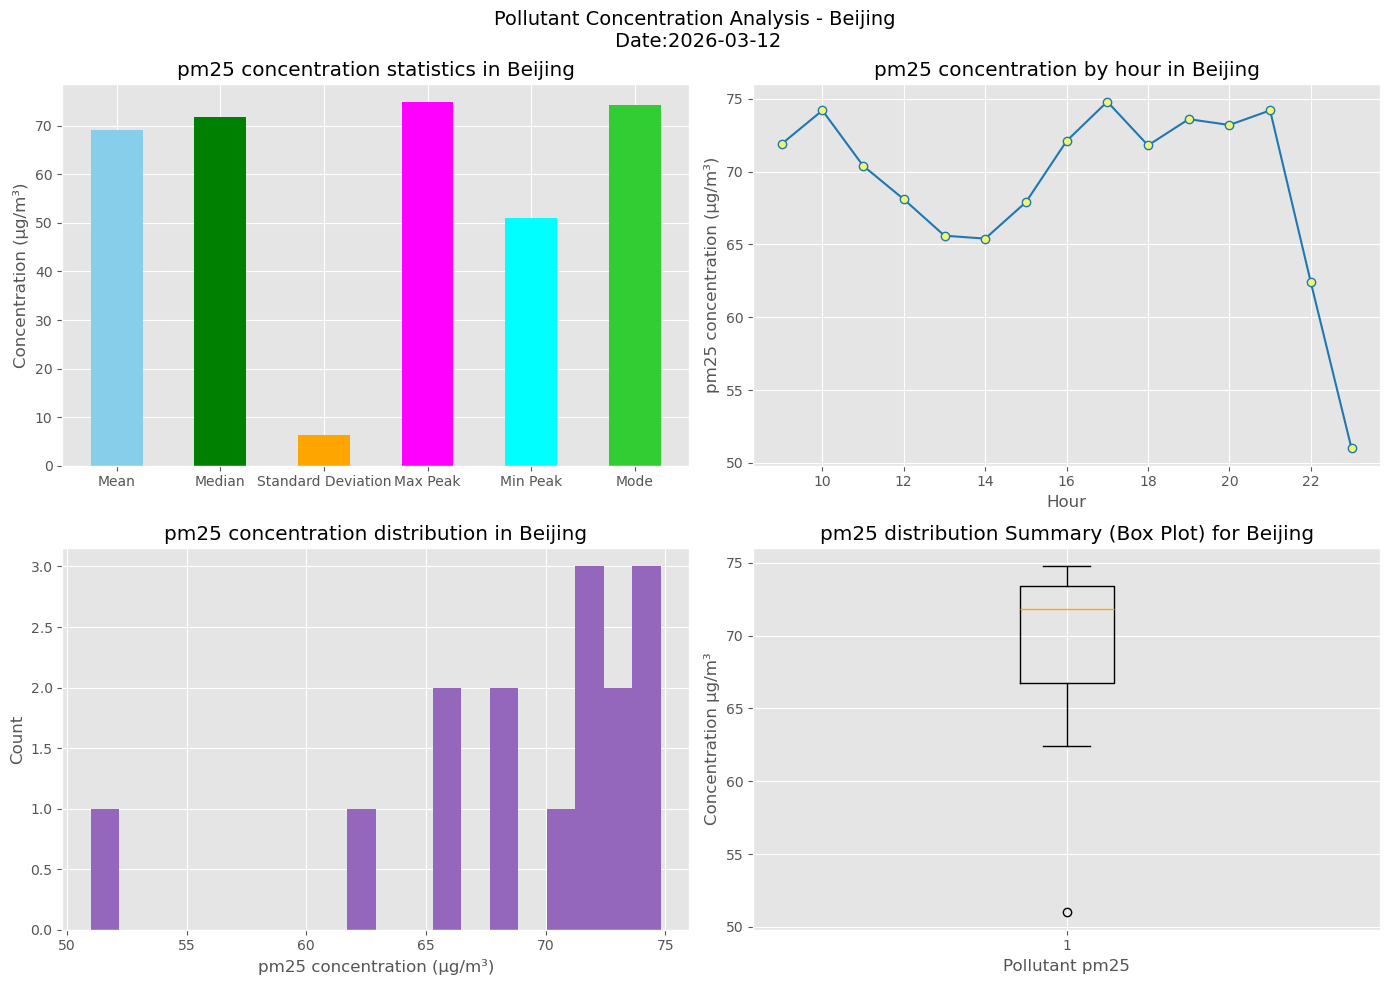

'no' pollutant not found in the Beijing dataframe.
'no2' pollutant not found in the Beijing dataframe.
'nox' pollutant not found in the Beijing dataframe.
'co' pollutant not found in the Beijing dataframe.
'o3' pollutant not found in the Beijing dataframe.
'so2' pollutant not found in the Beijing dataframe.


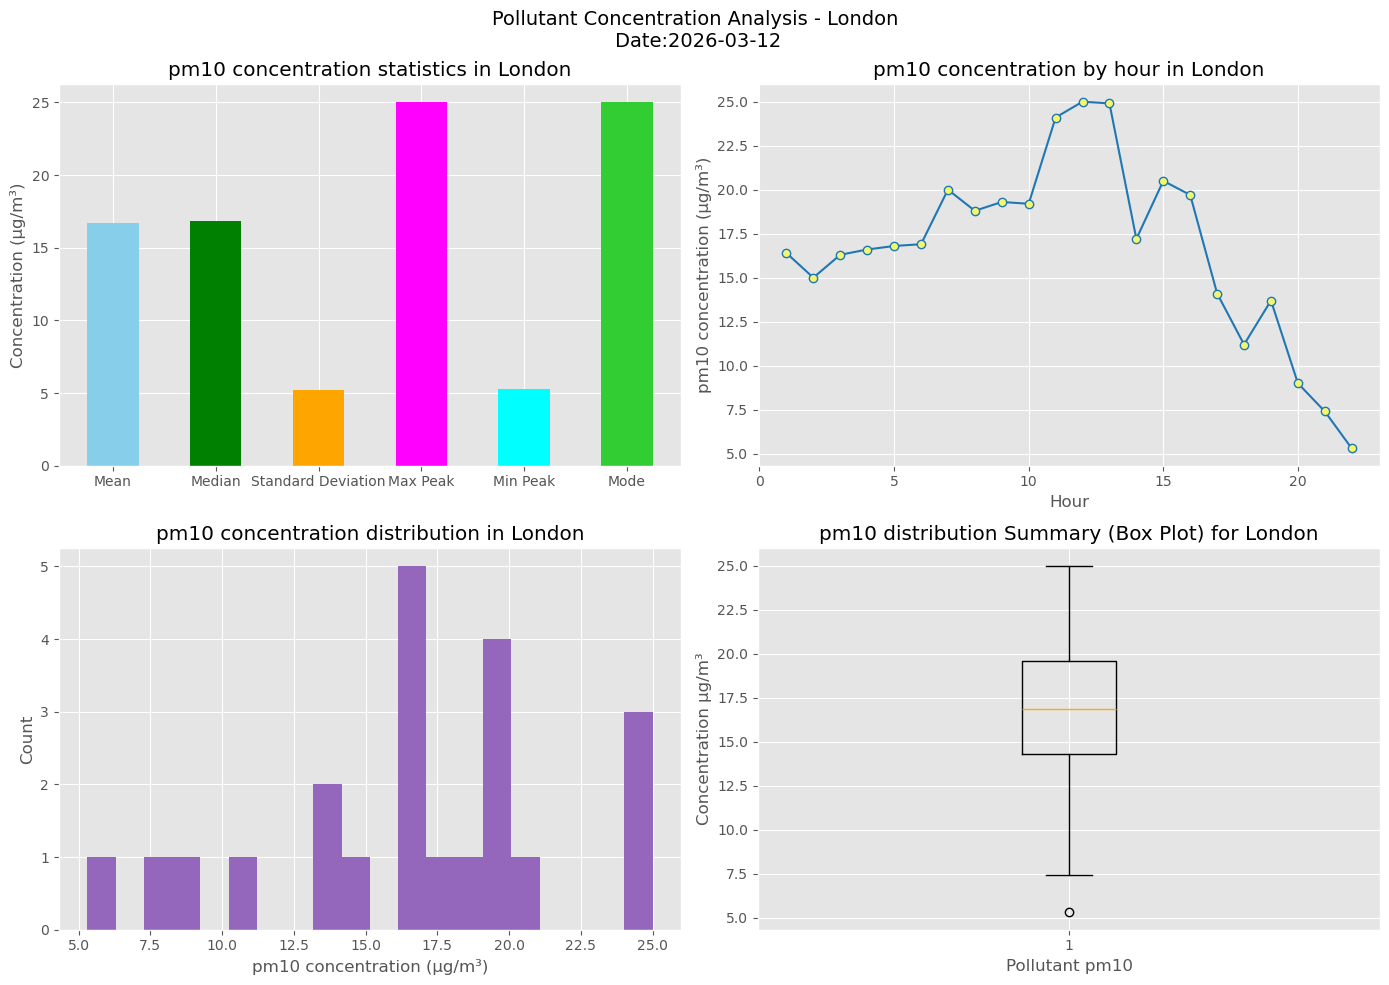

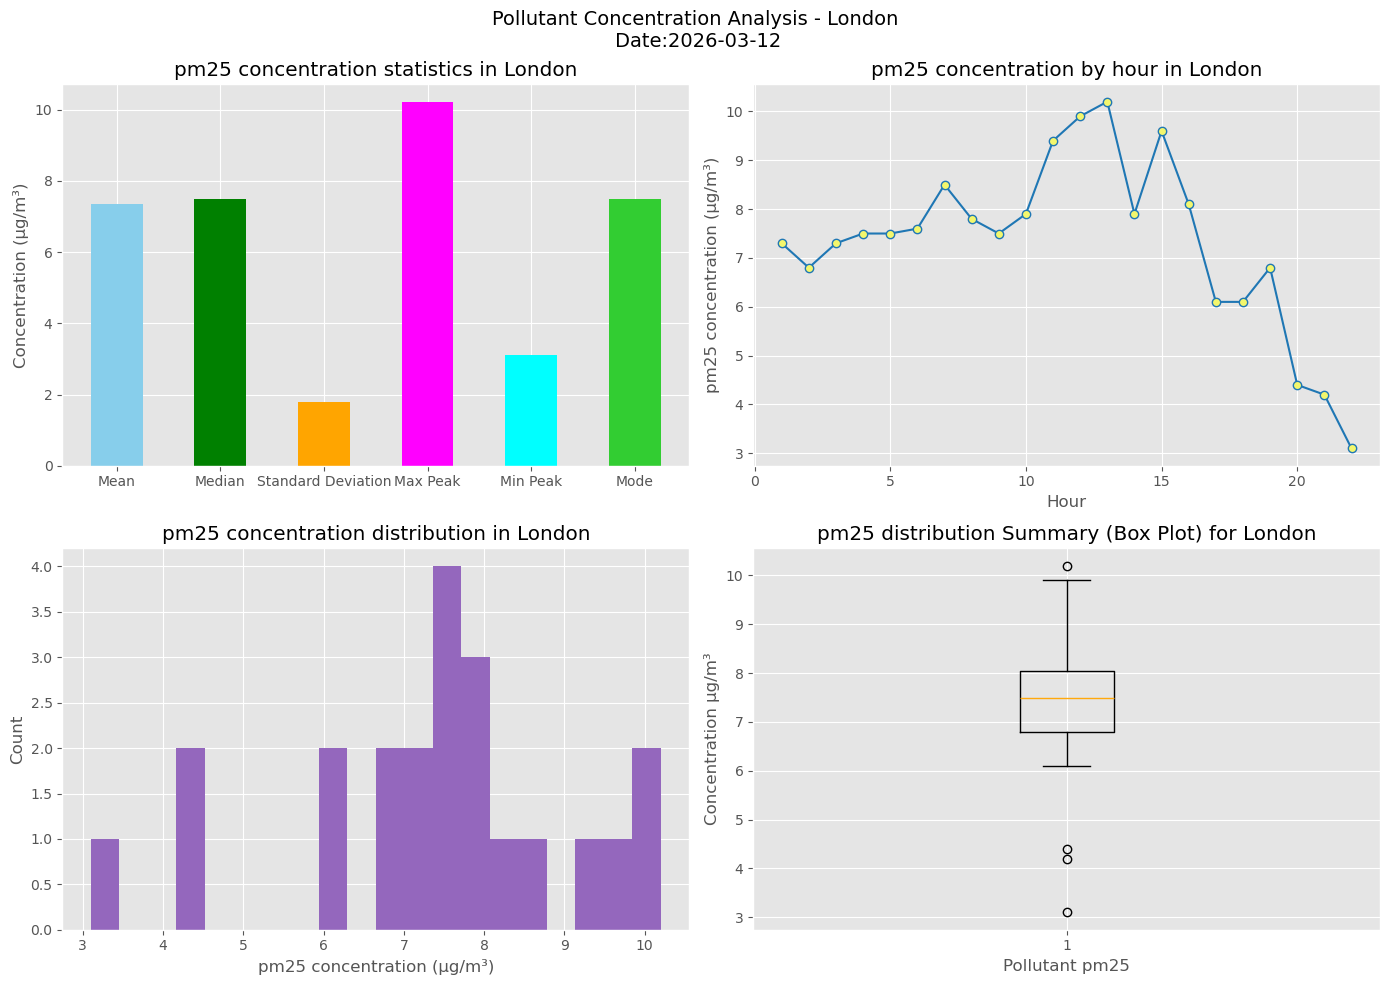

'no' pollutant not found in the London dataframe.
'no2' pollutant not found in the London dataframe.
'nox' pollutant not found in the London dataframe.
'co' pollutant not found in the London dataframe.


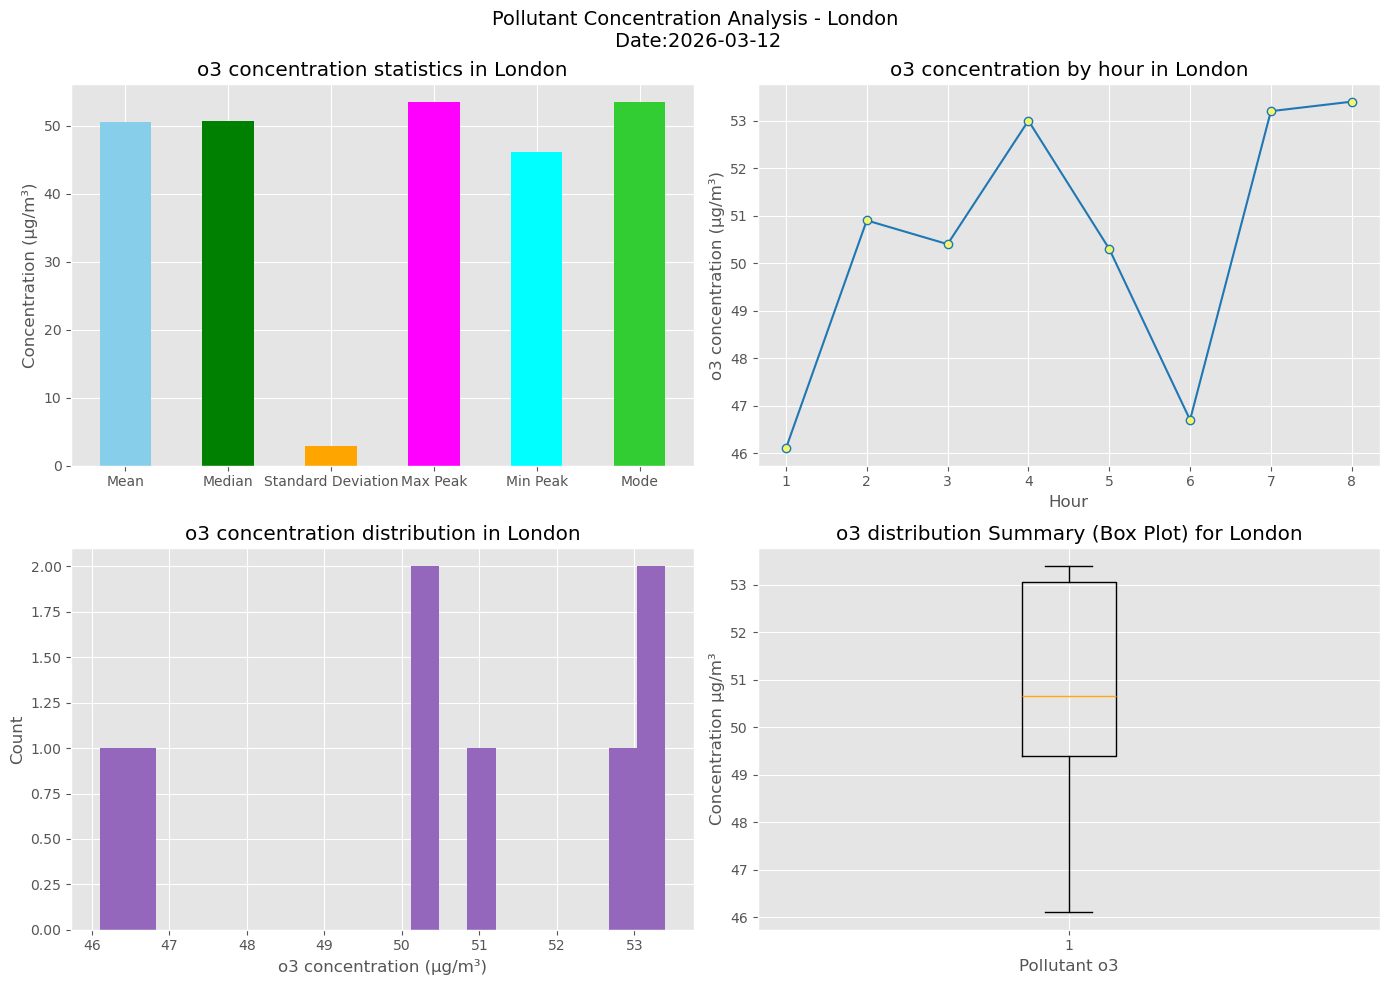

'so2' pollutant not found in the London dataframe.
'pm10' pollutant not found in the Los Angeles dataframe.


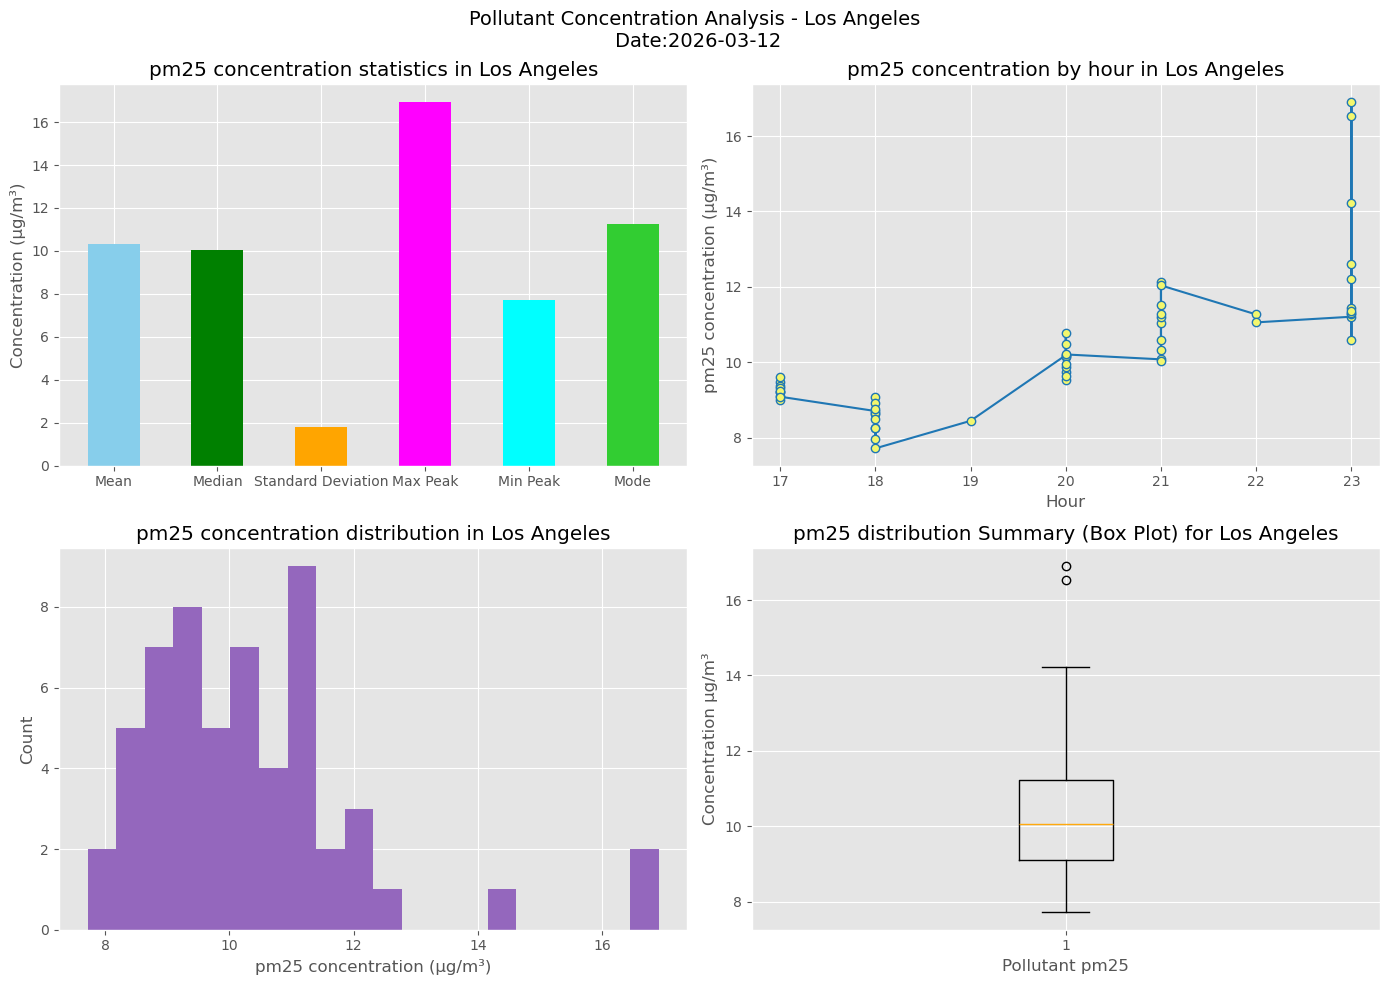

'no' pollutant not found in the Los Angeles dataframe.
'no2' pollutant not found in the Los Angeles dataframe.
'nox' pollutant not found in the Los Angeles dataframe.
'co' pollutant not found in the Los Angeles dataframe.
'o3' pollutant not found in the Los Angeles dataframe.
'so2' pollutant not found in the Los Angeles dataframe.


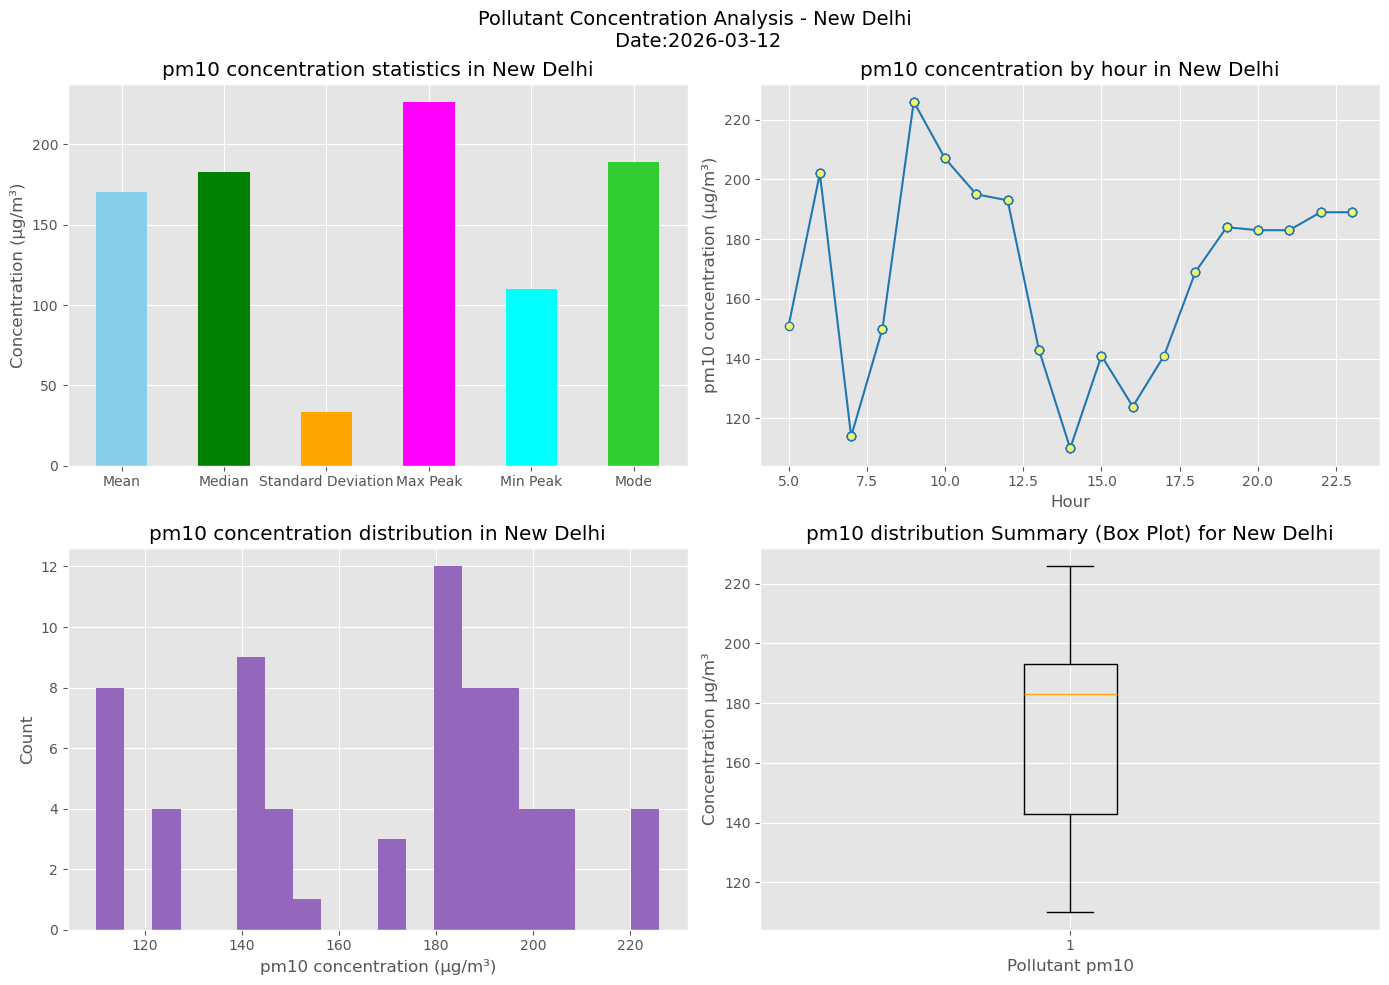

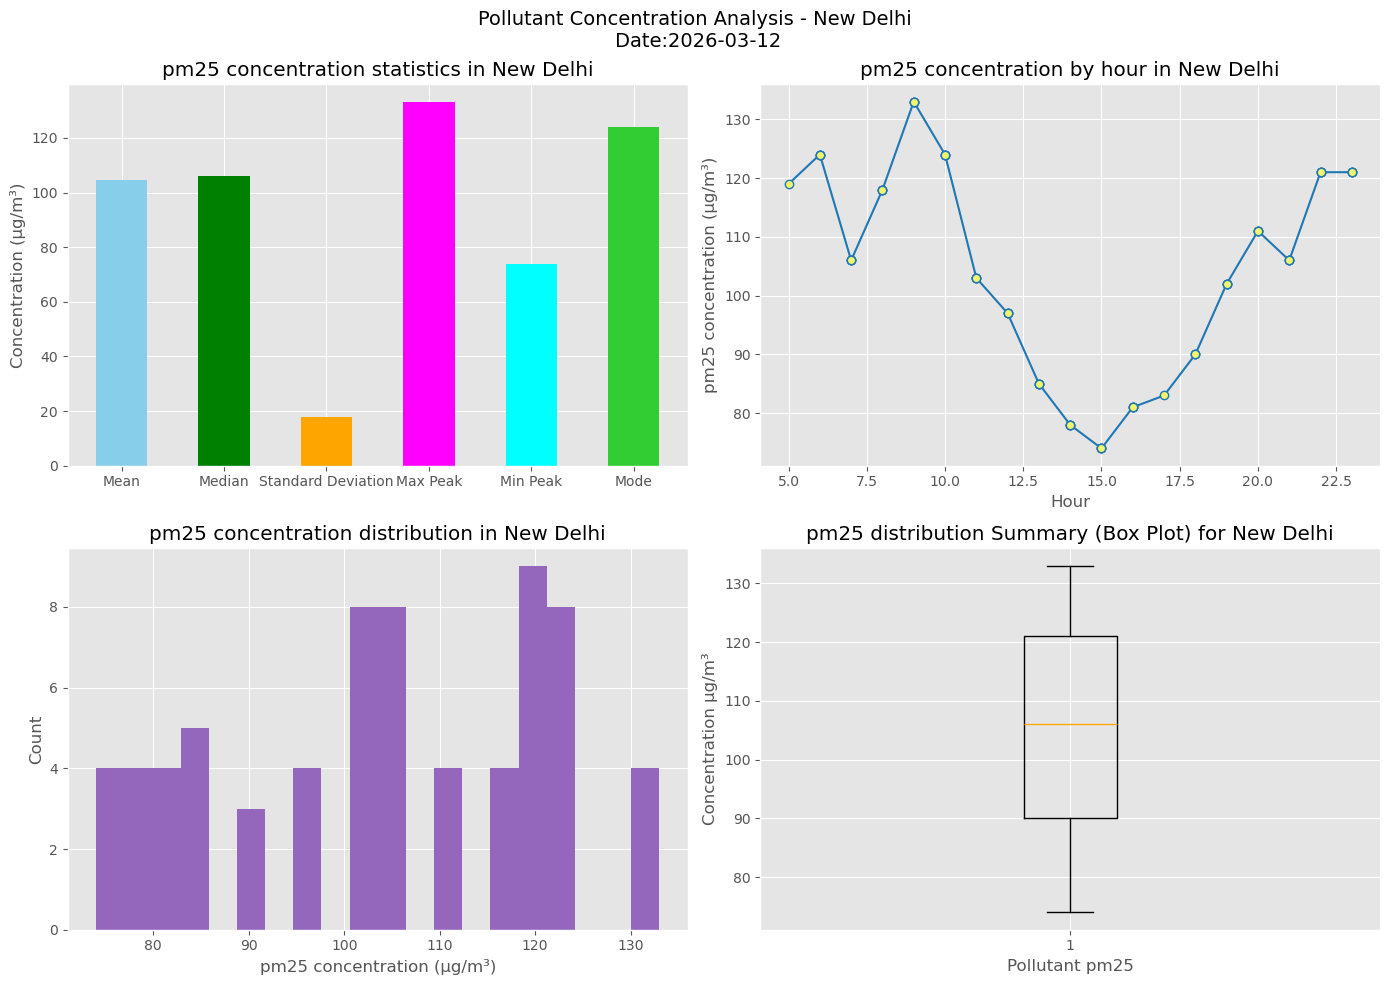

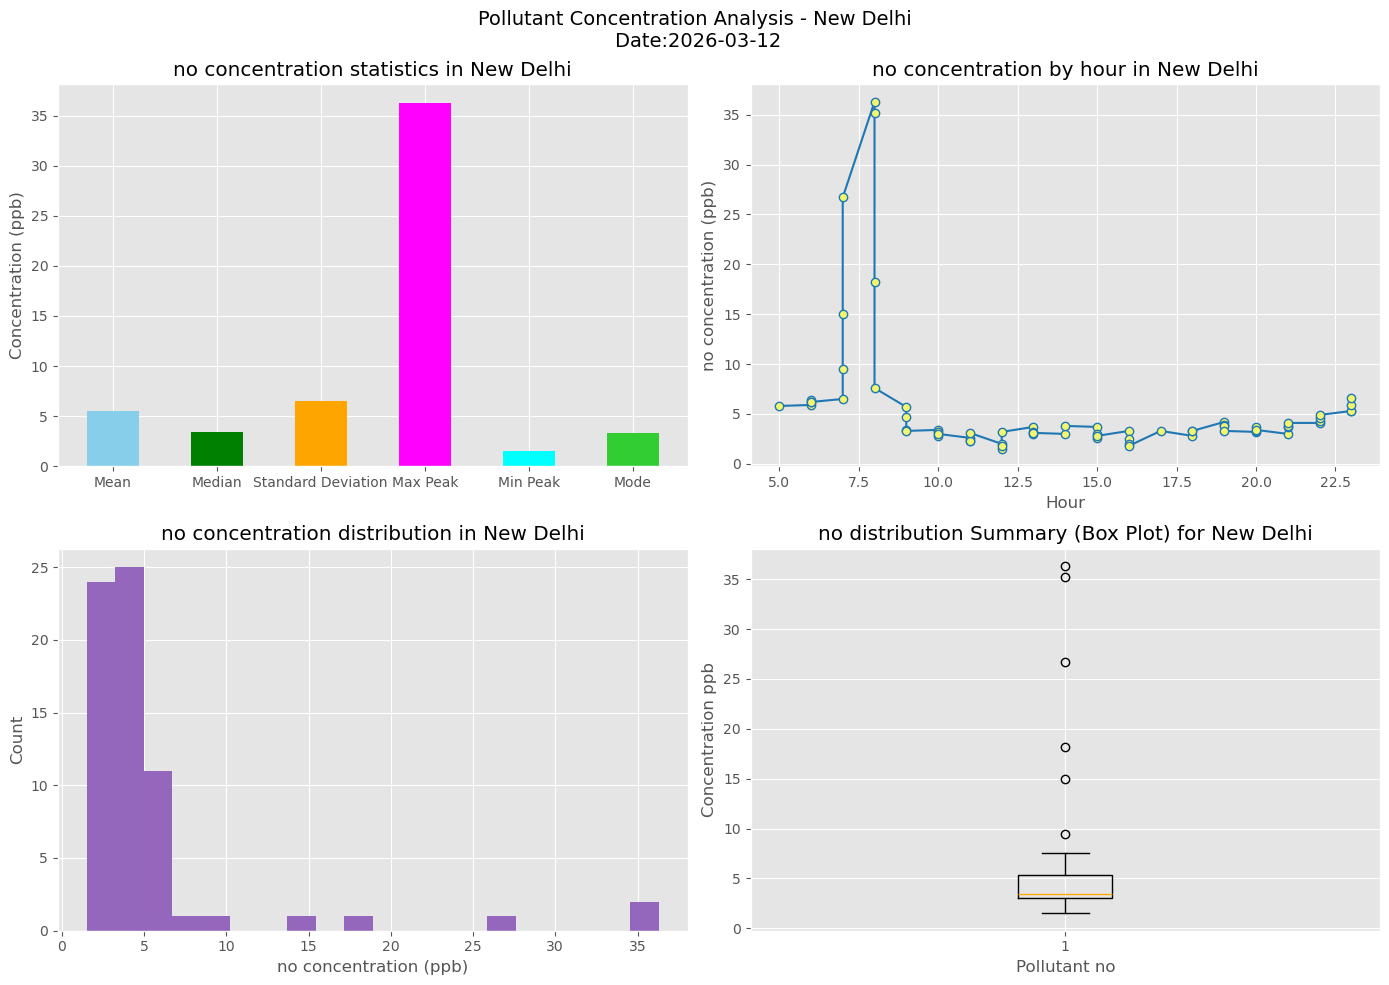

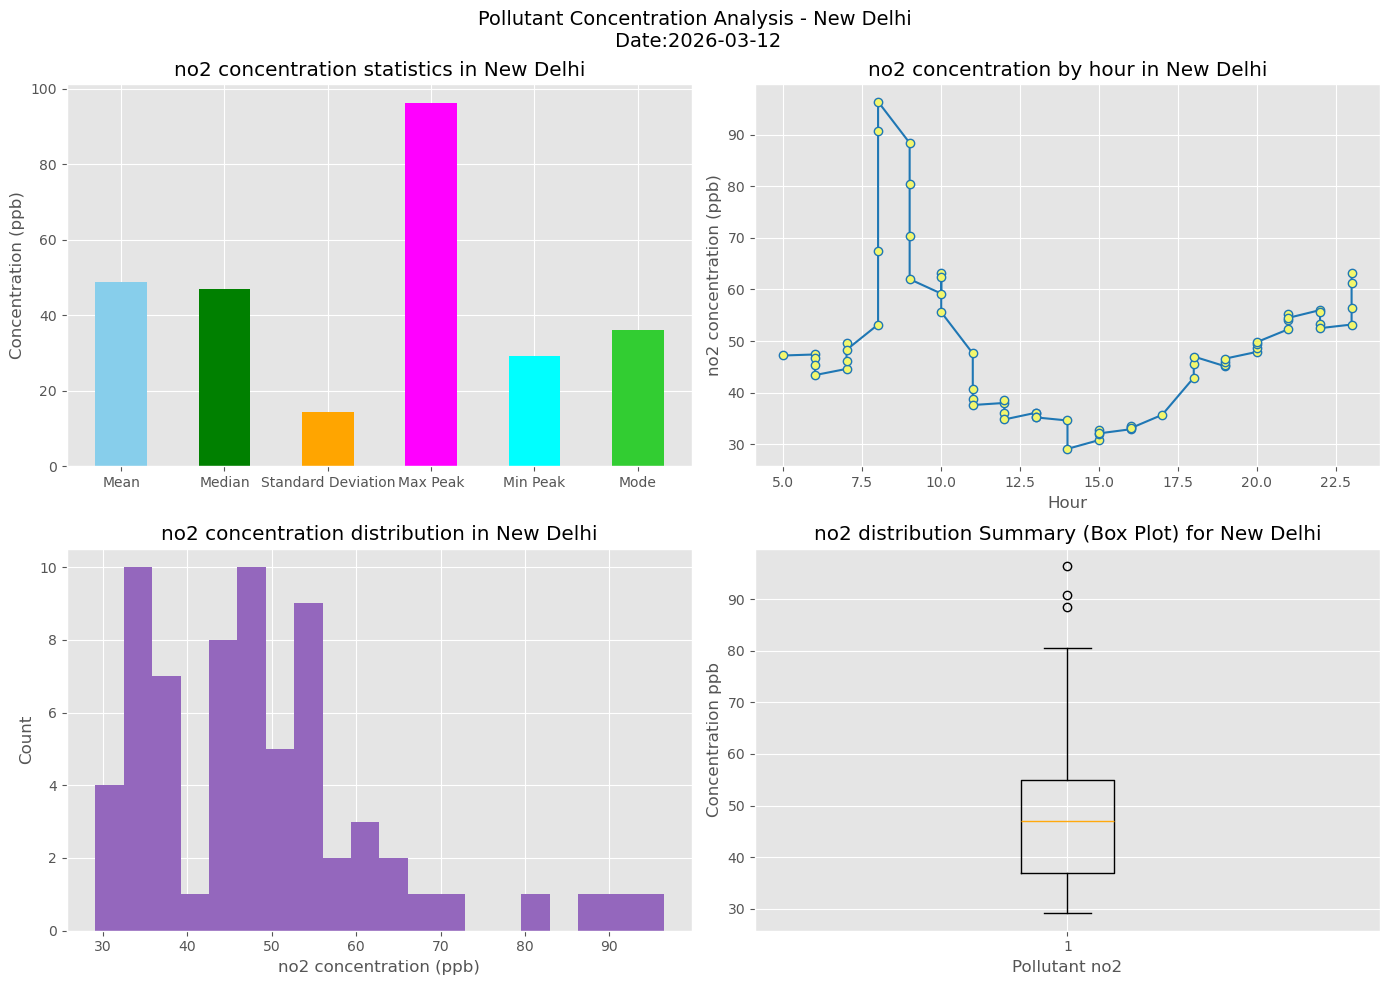

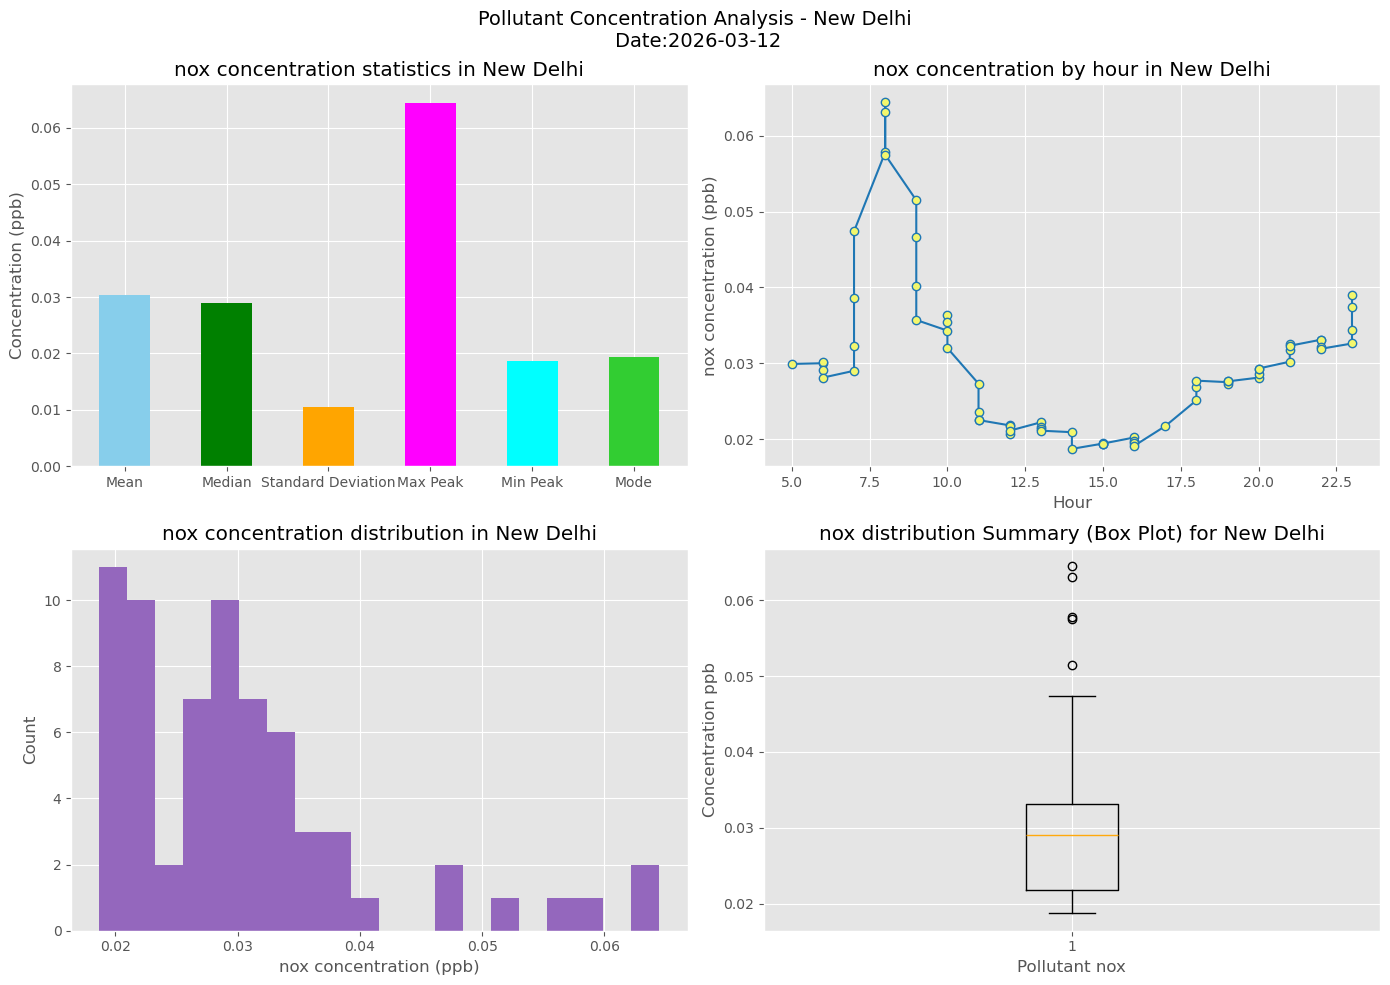

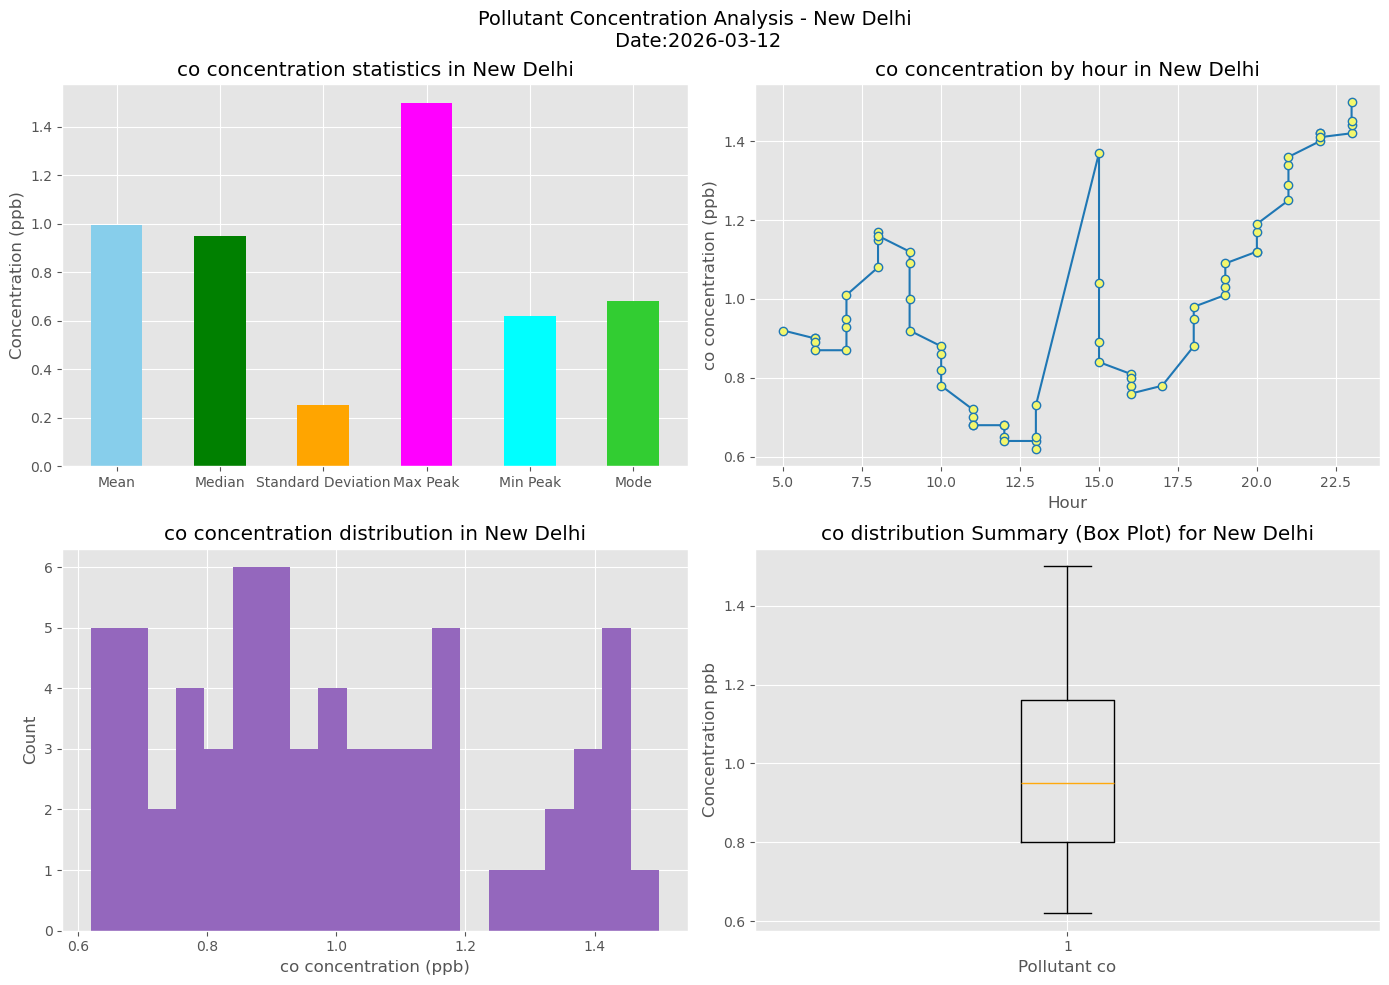

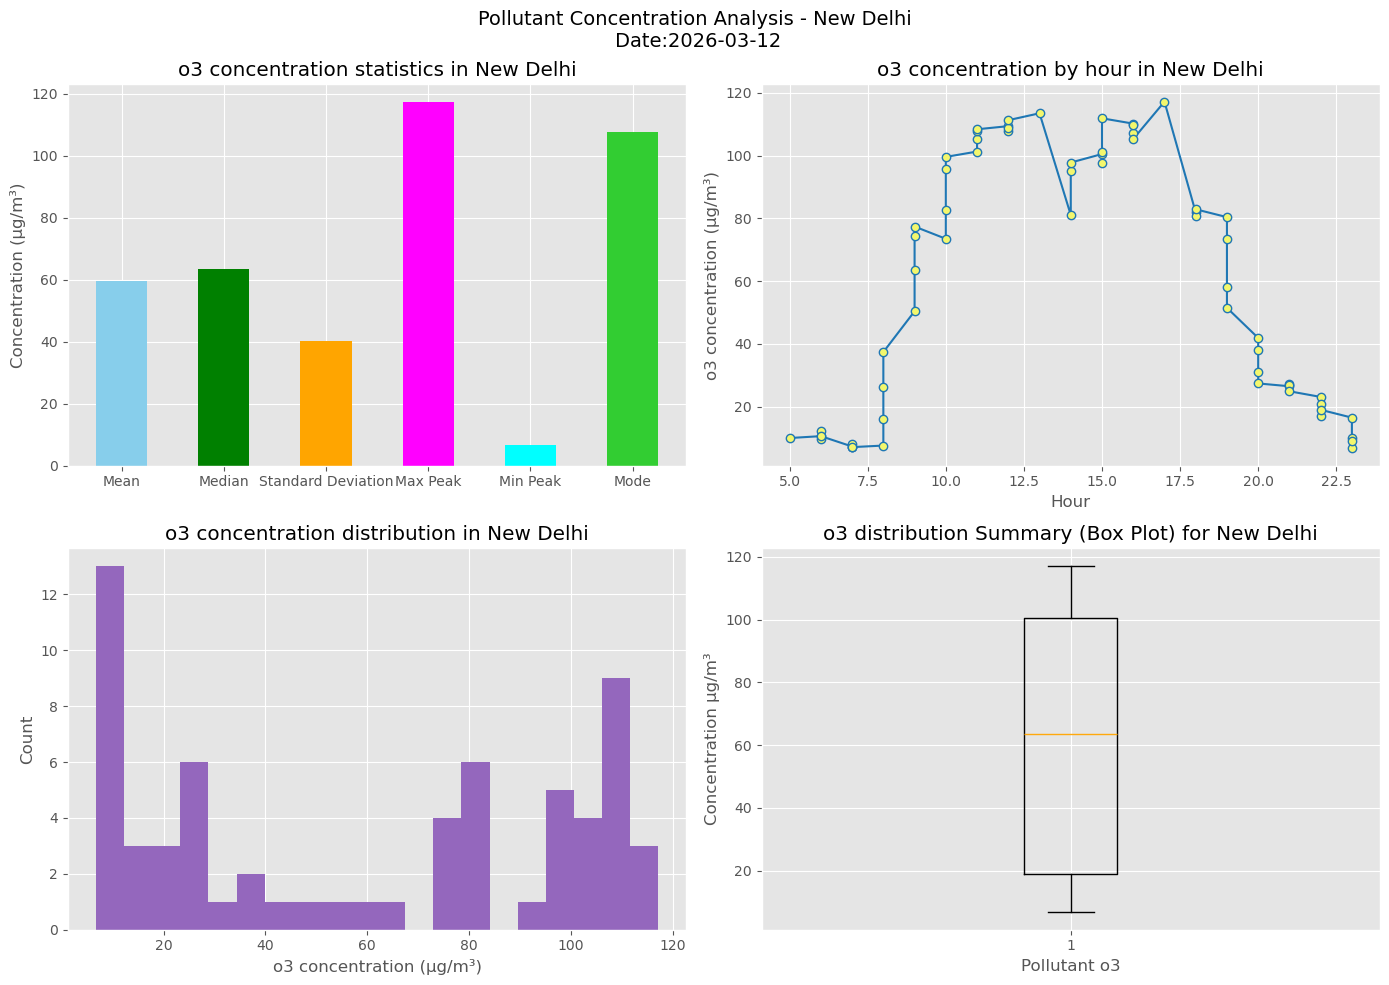

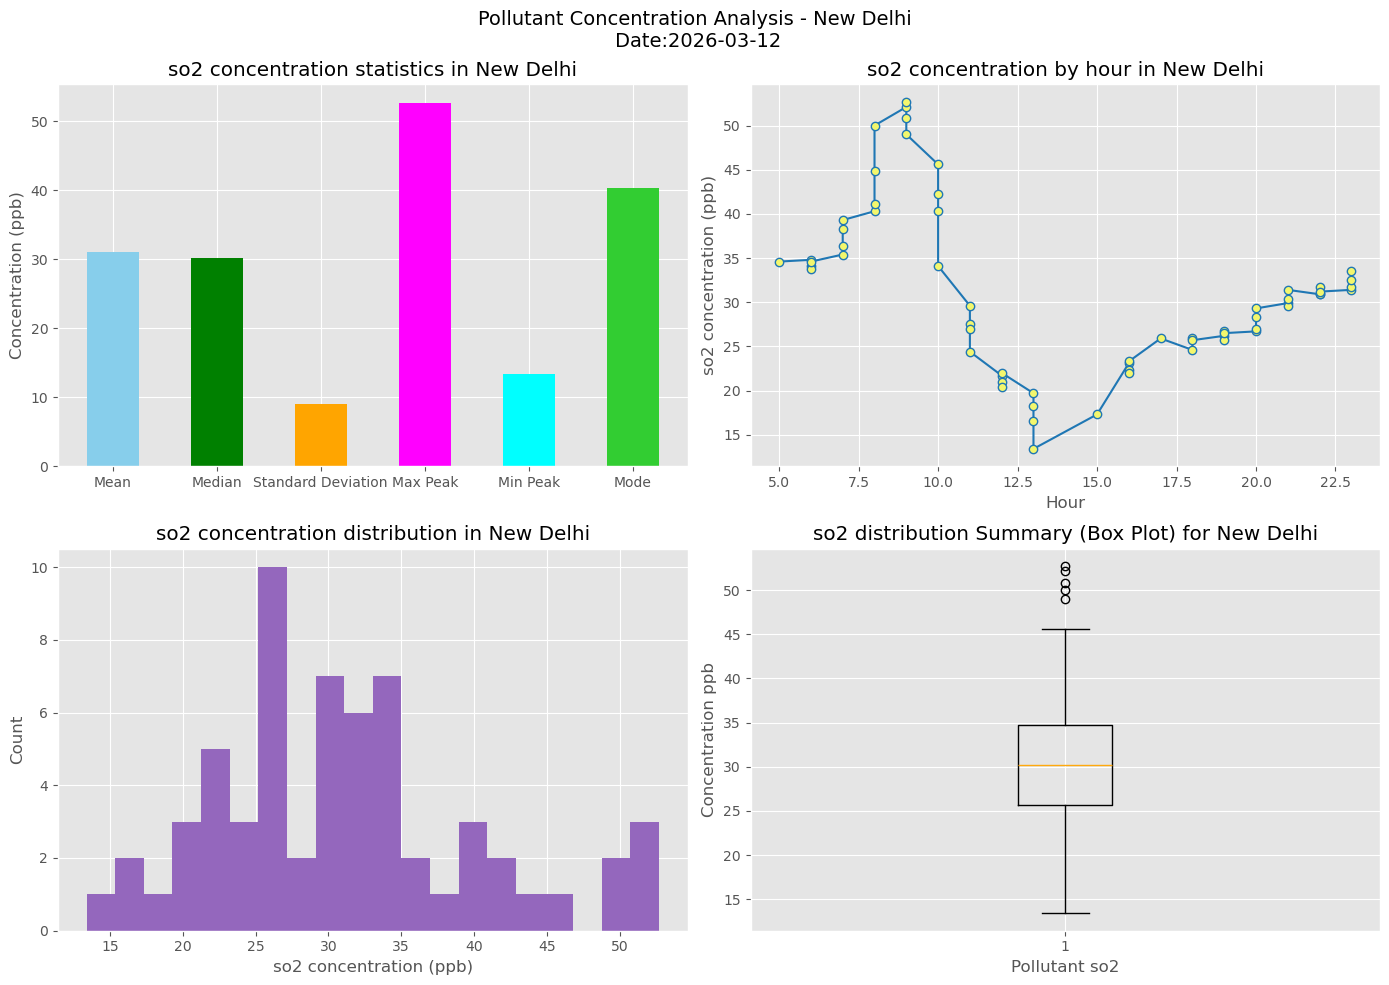

'pm10' pollutant not found in the New York dataframe.


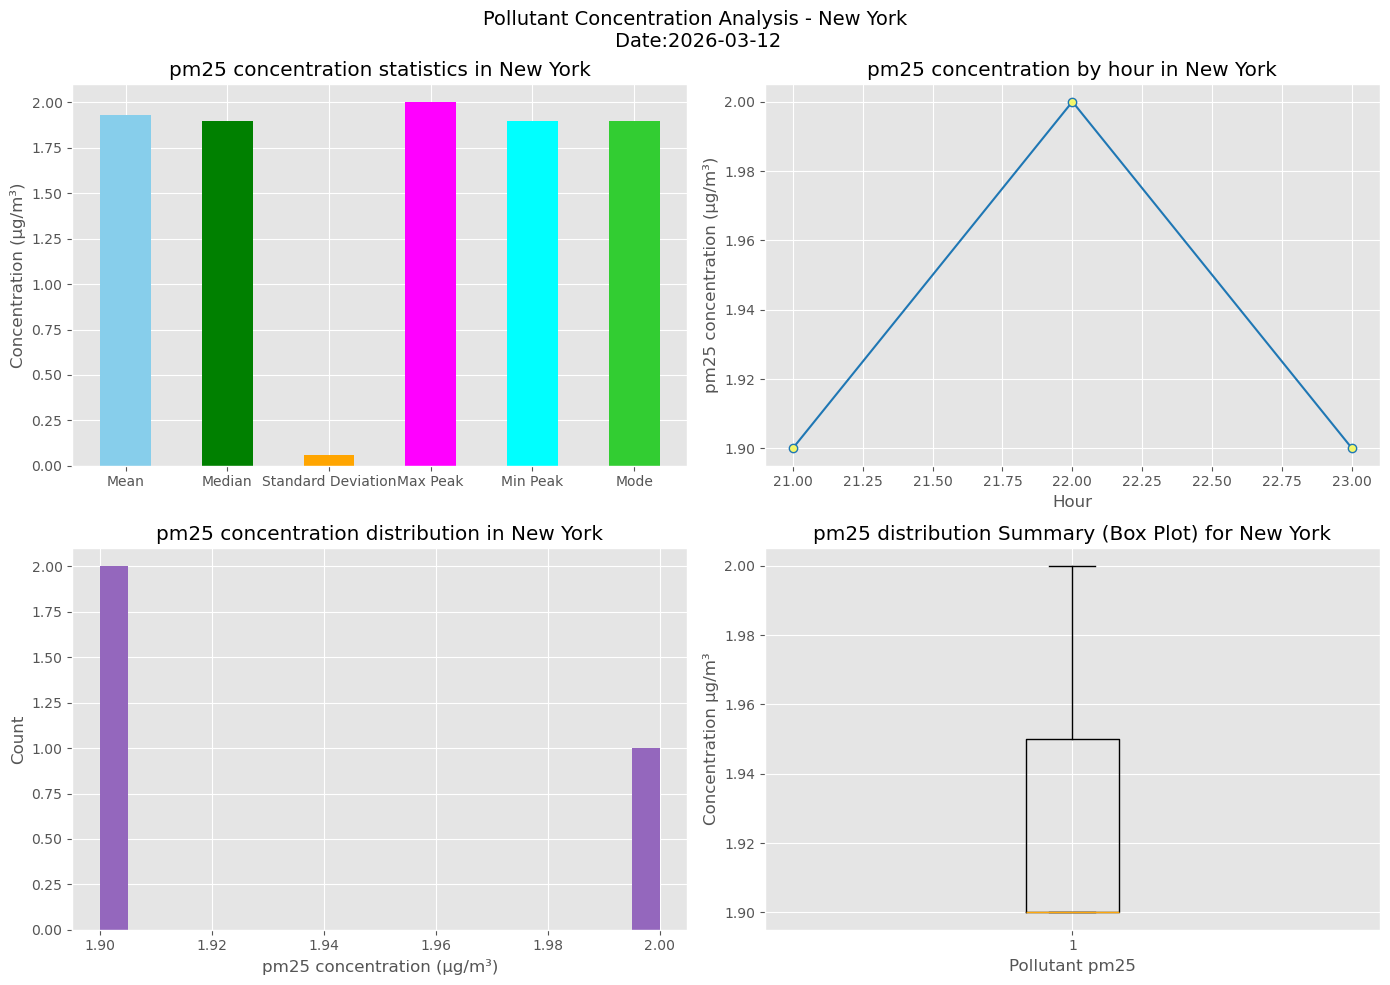

'no' pollutant not found in the New York dataframe.
'no2' pollutant not found in the New York dataframe.
'nox' pollutant not found in the New York dataframe.
'co' pollutant not found in the New York dataframe.


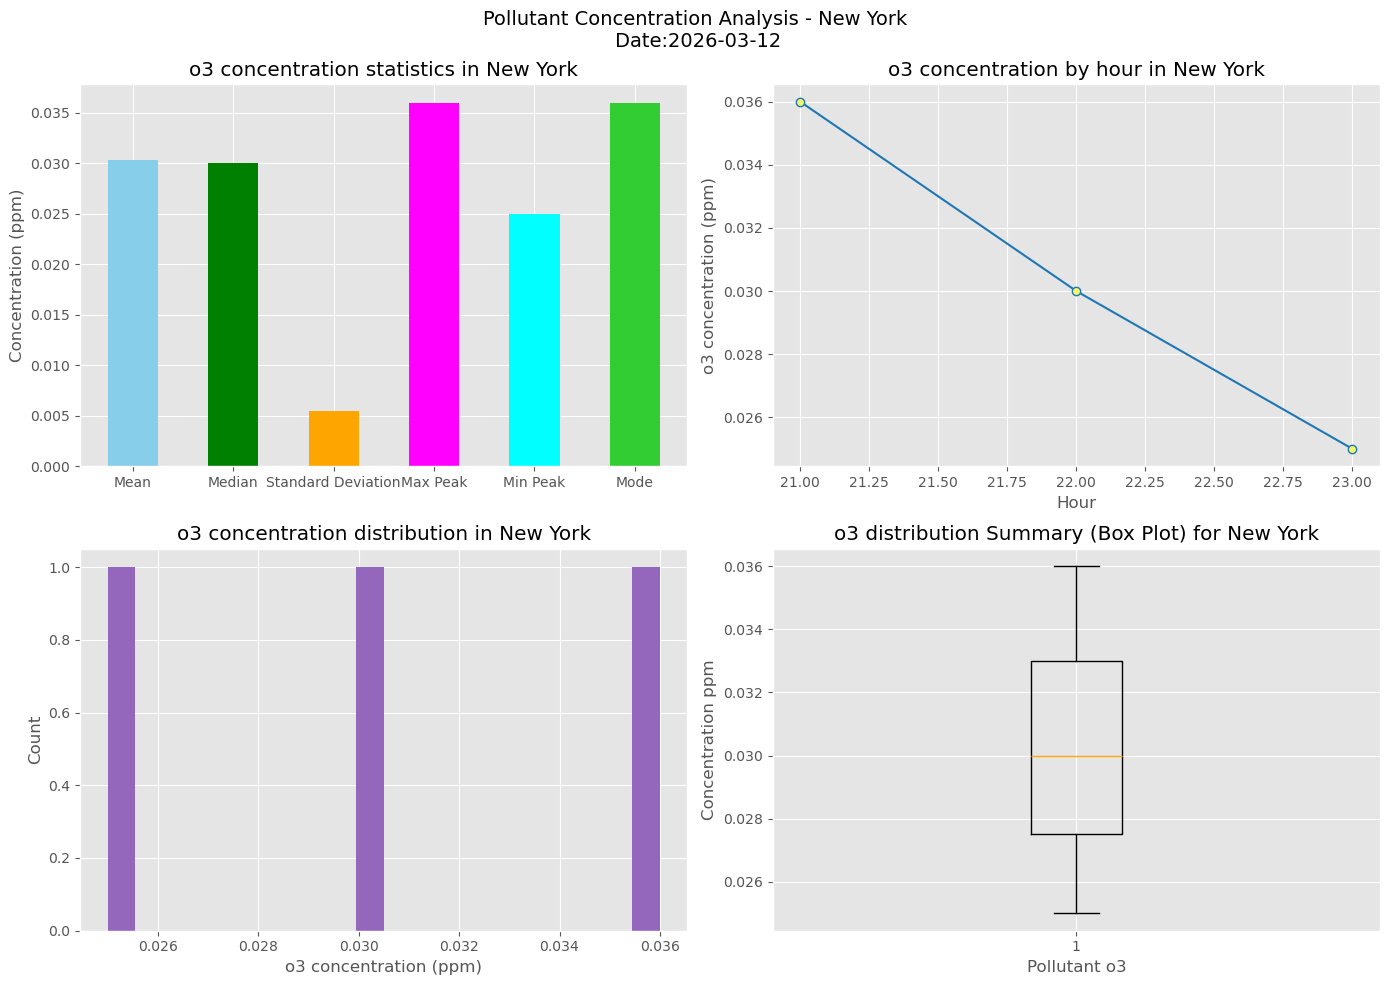

'so2' pollutant not found in the New York dataframe.


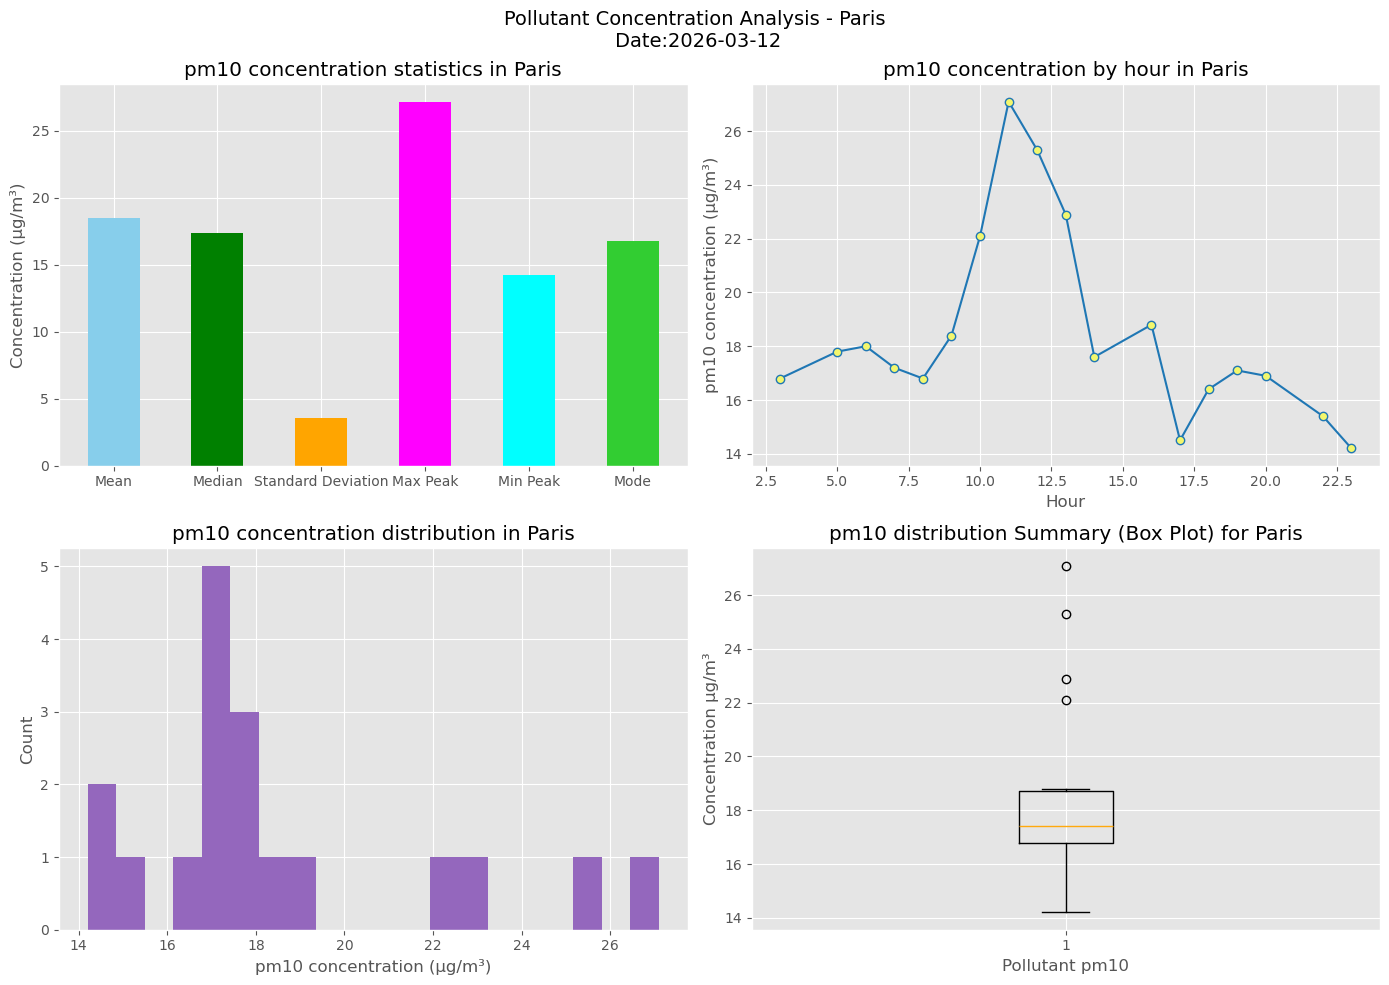

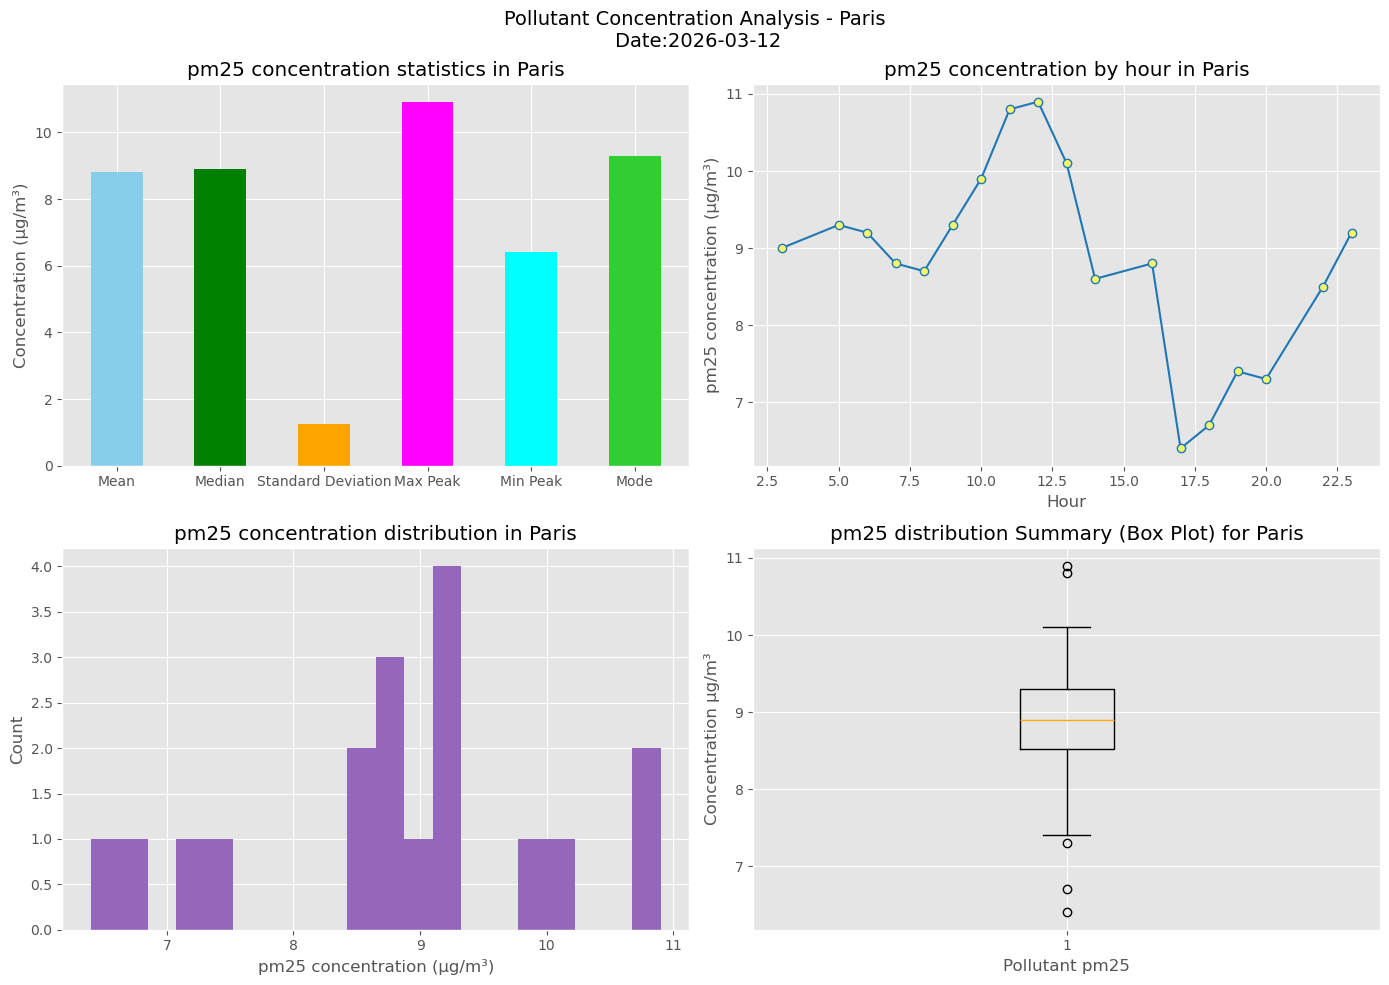

'no' pollutant not found in the Paris dataframe.


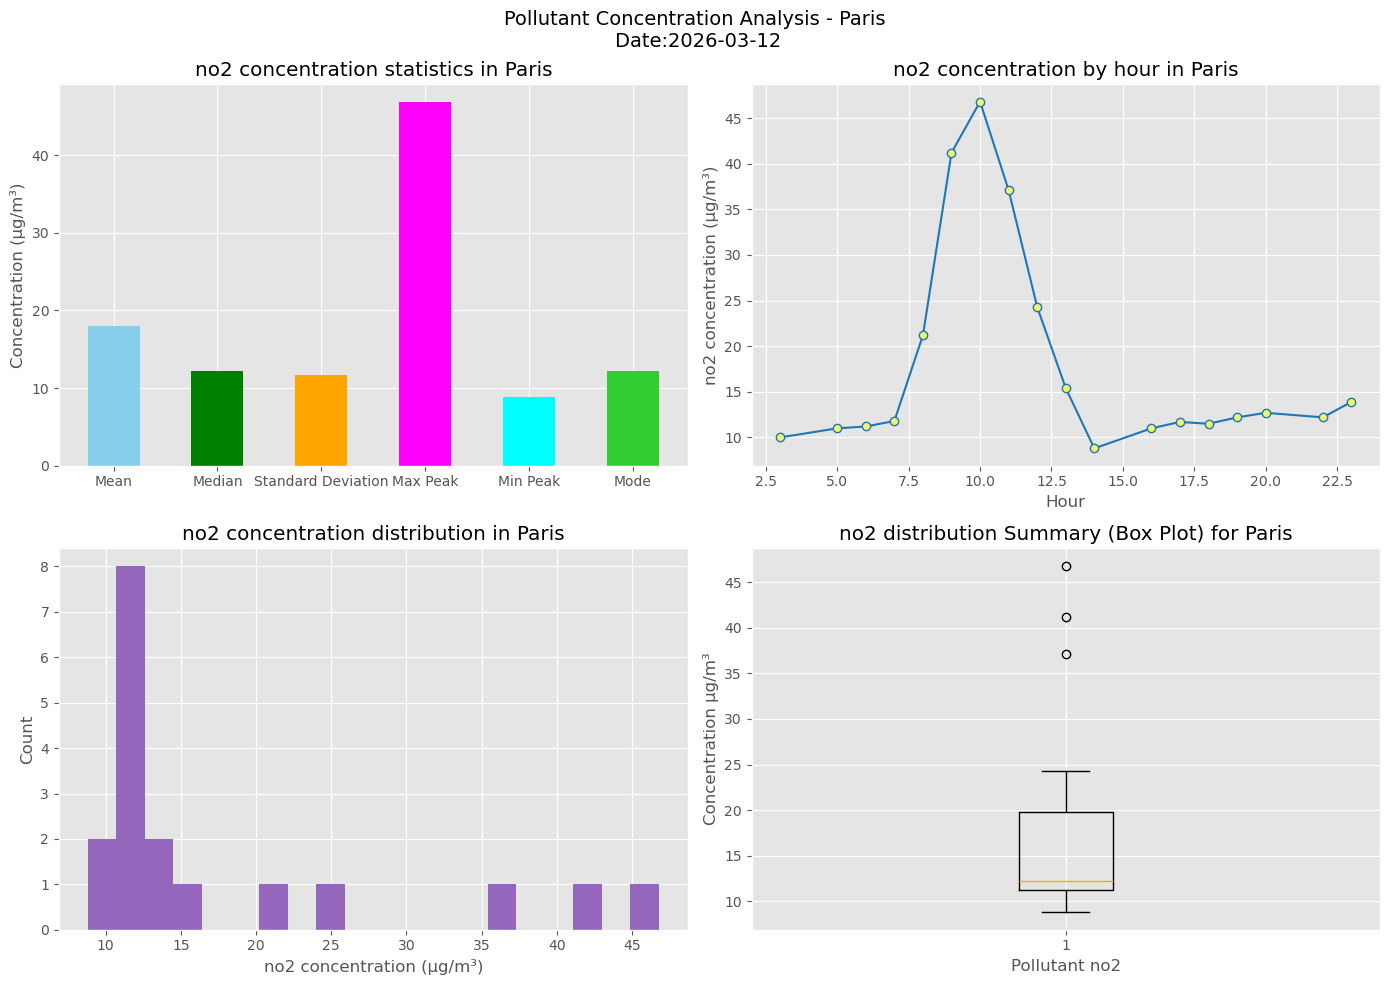

'nox' pollutant not found in the Paris dataframe.


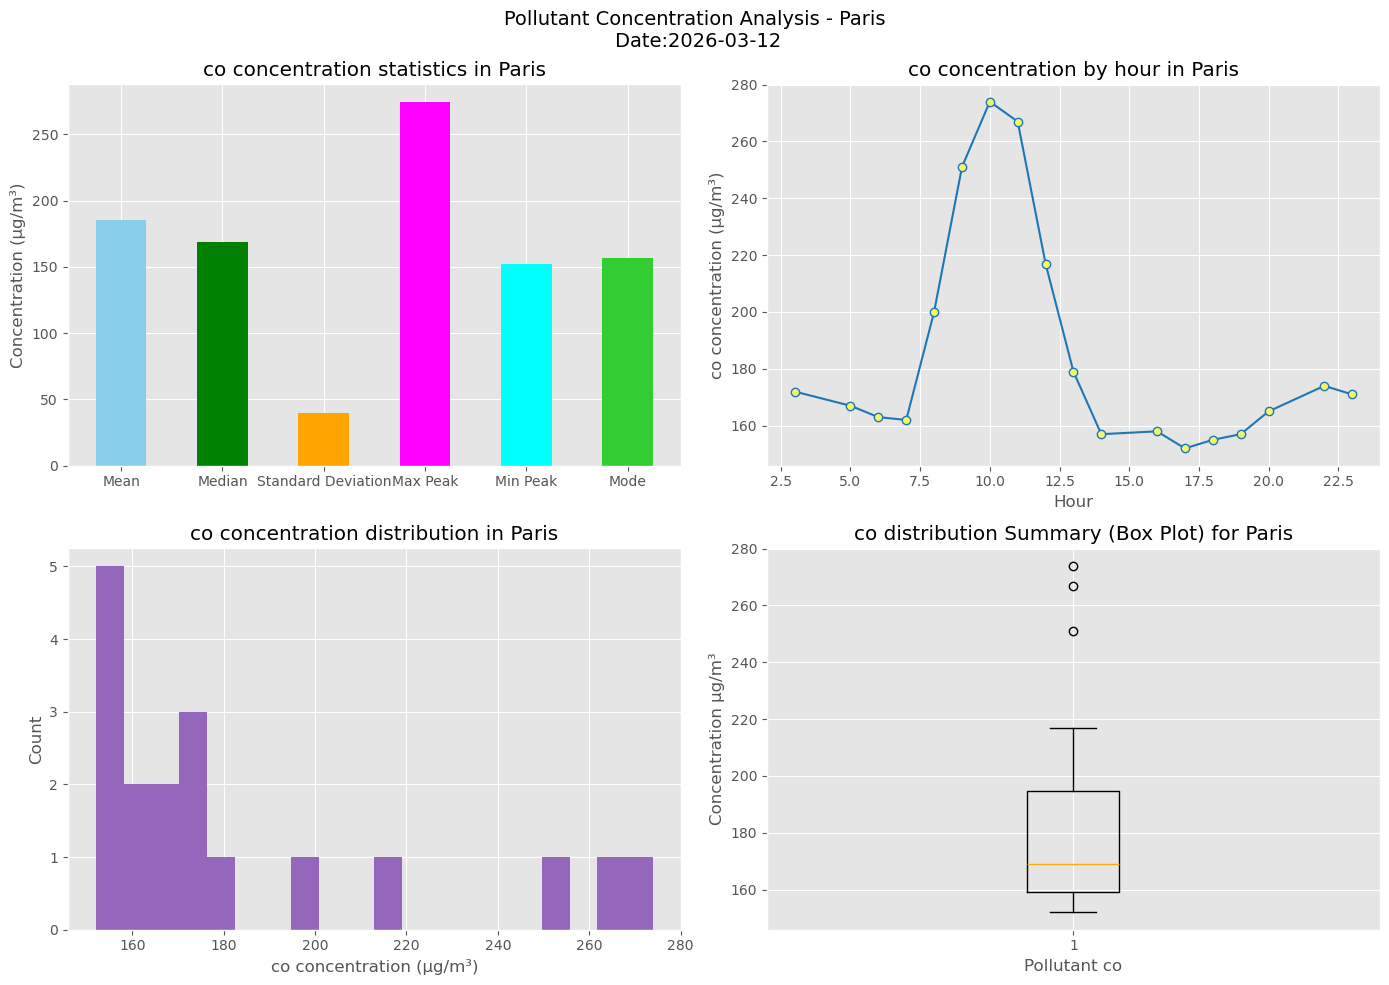

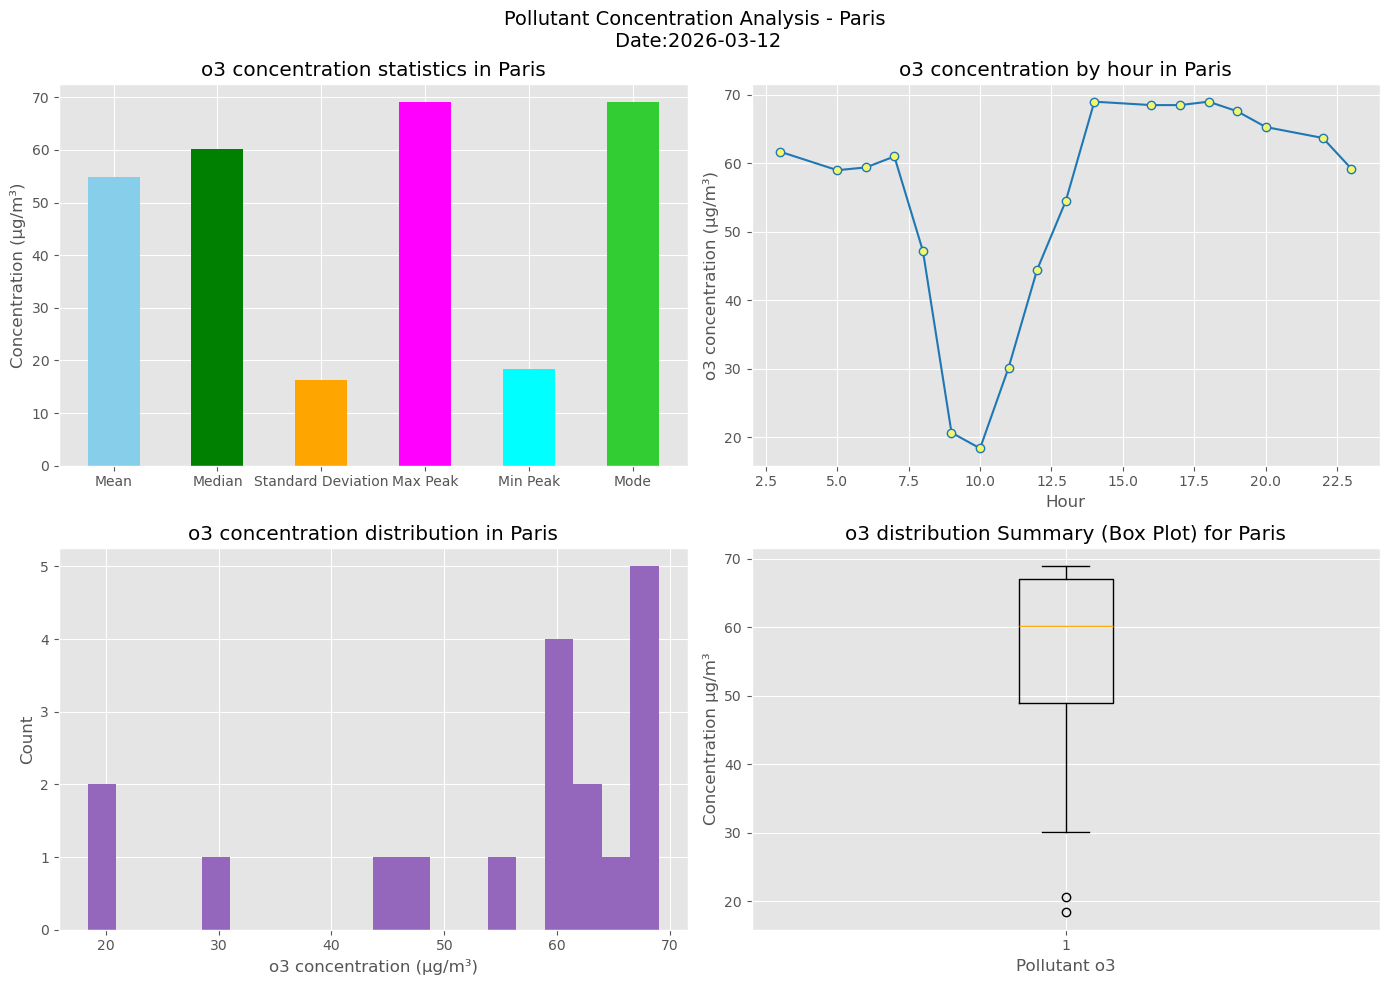

'so2' pollutant not found in the Paris dataframe.
'pm10' pollutant not found in the Tokyo dataframe.


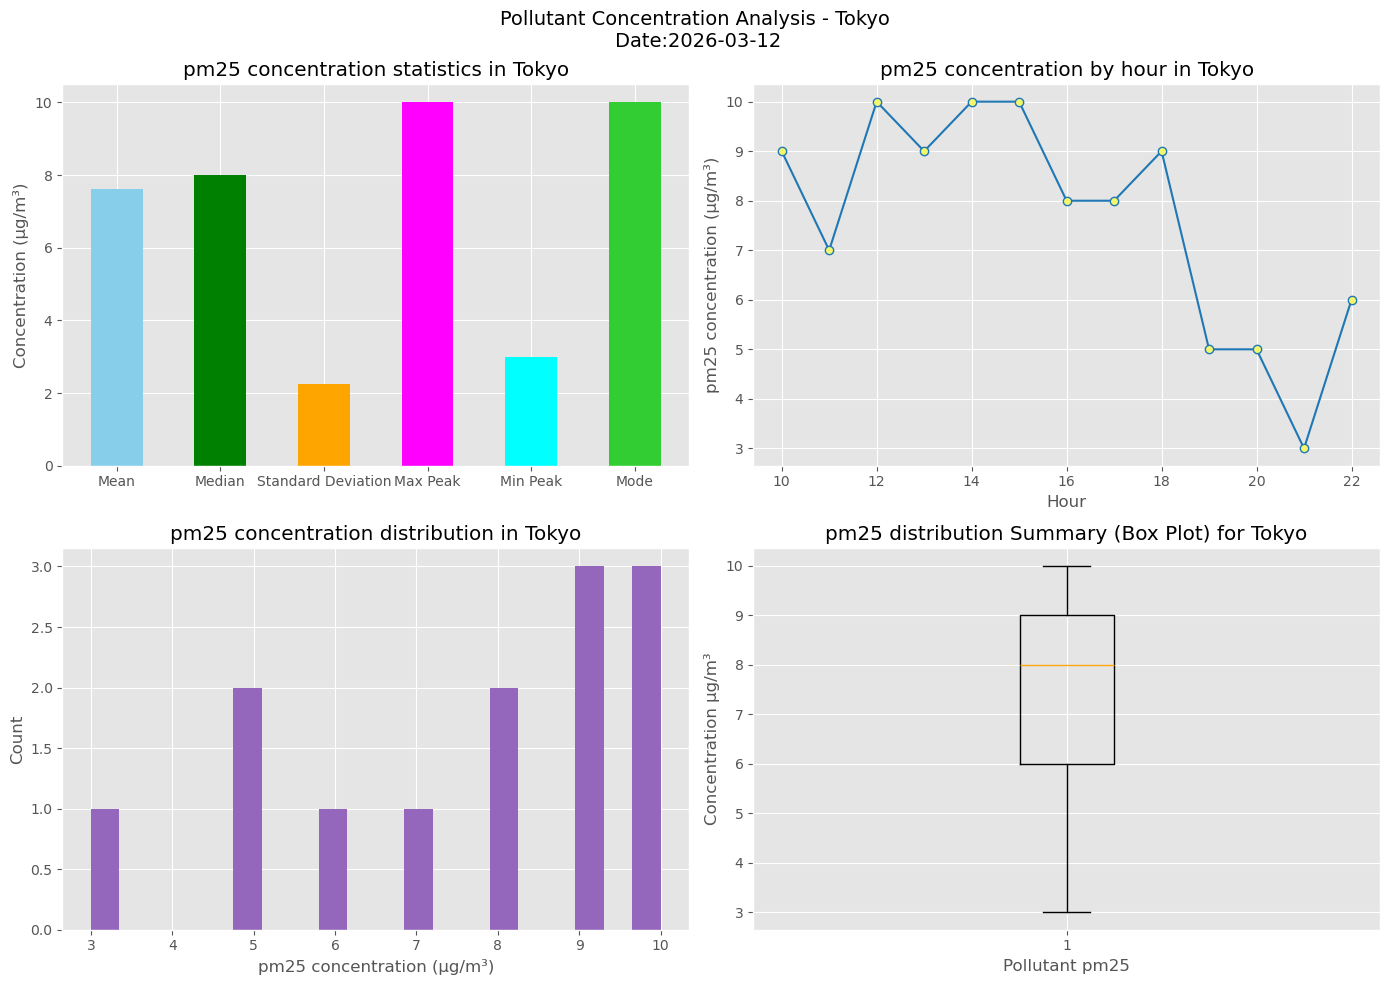

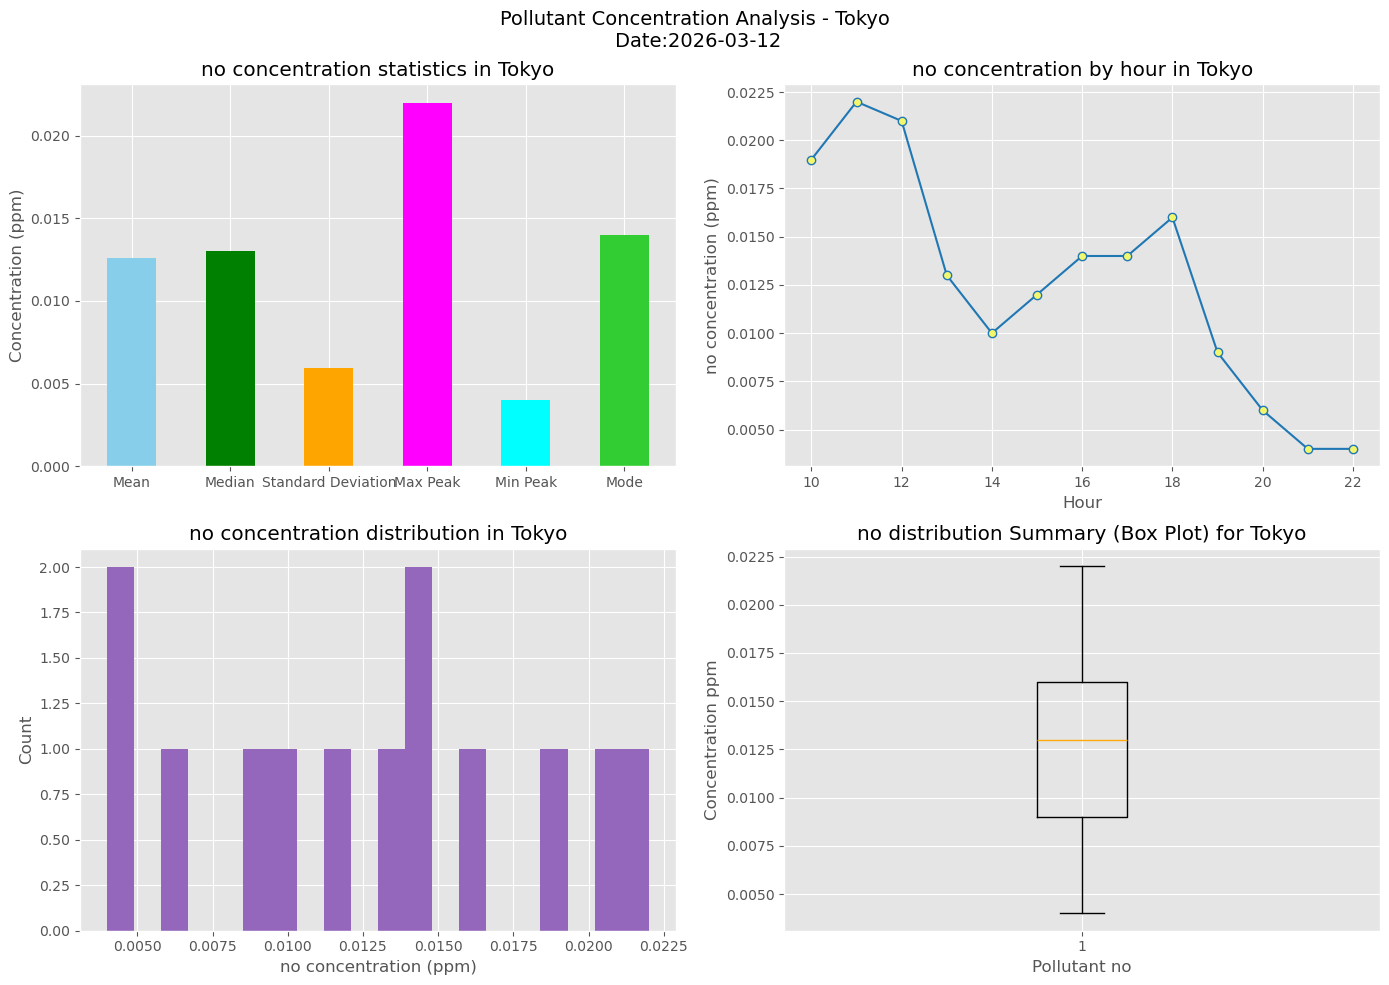

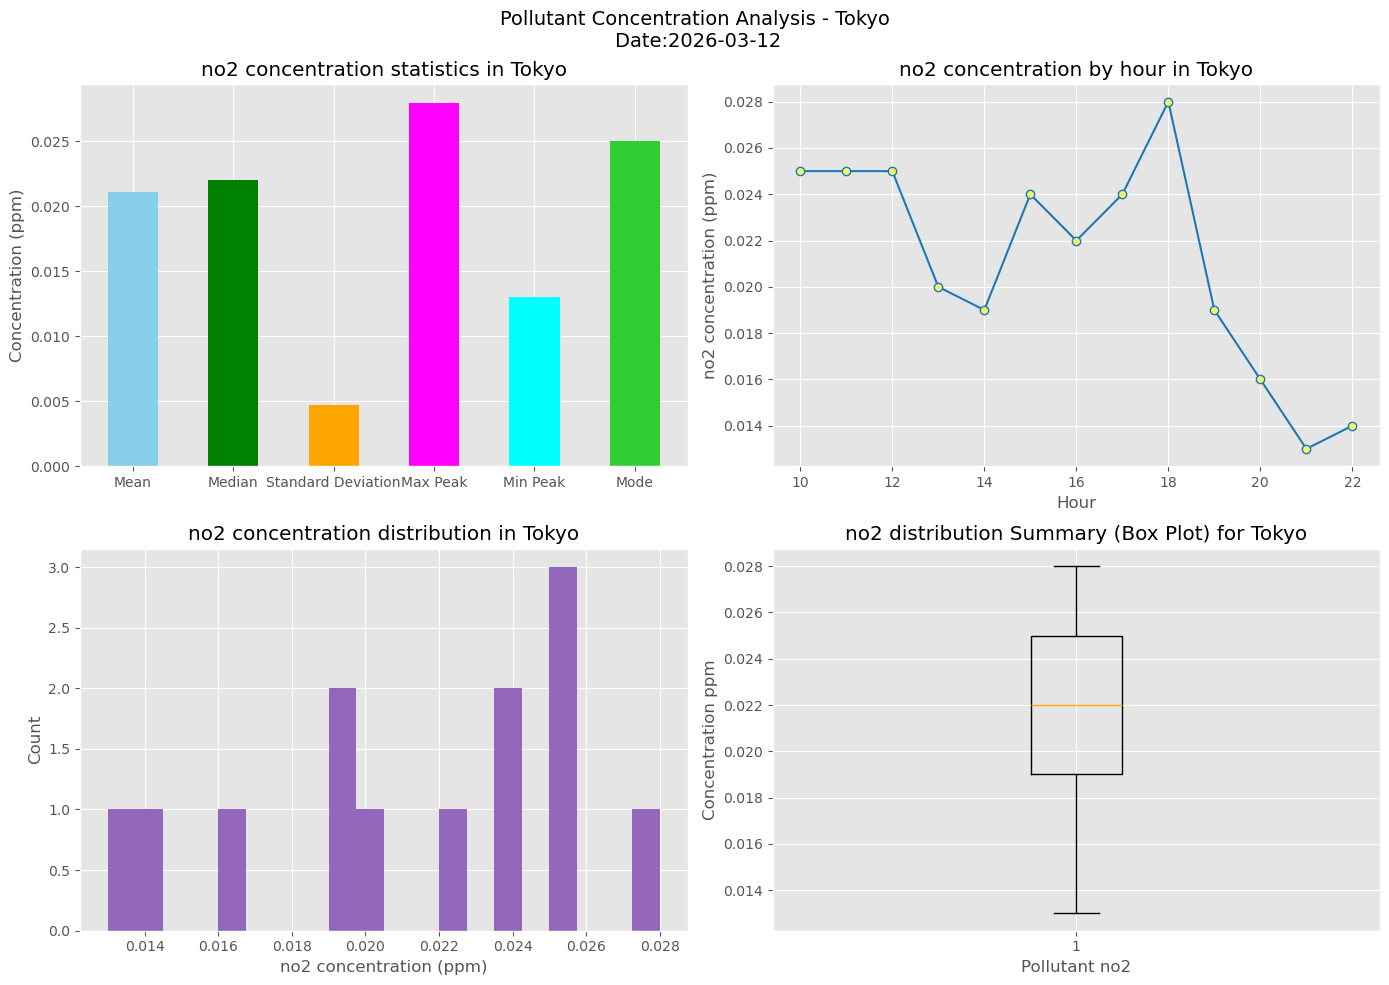

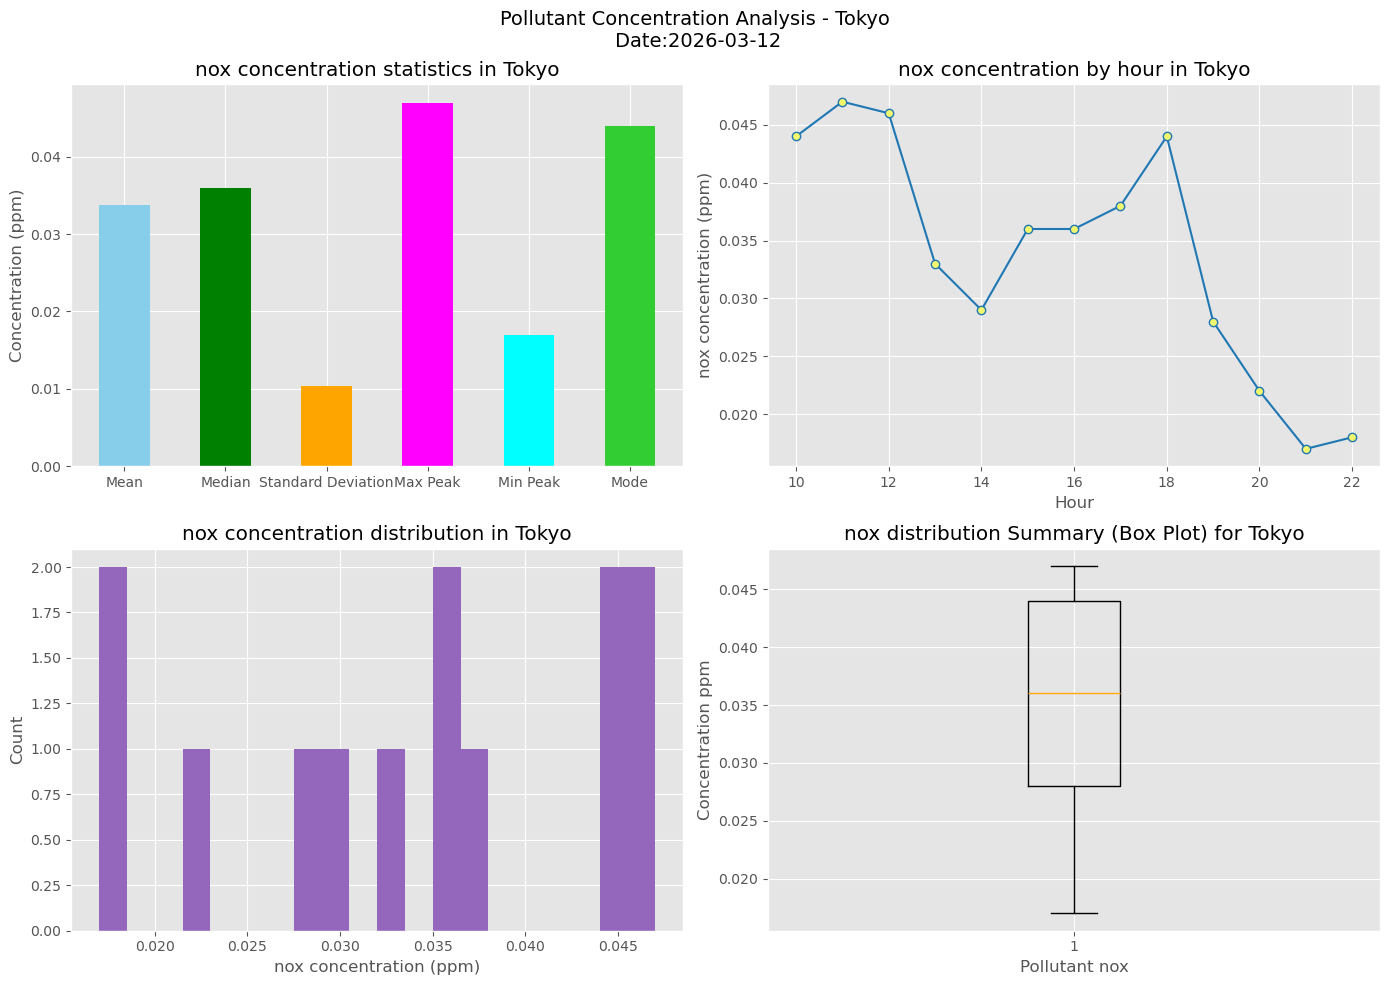

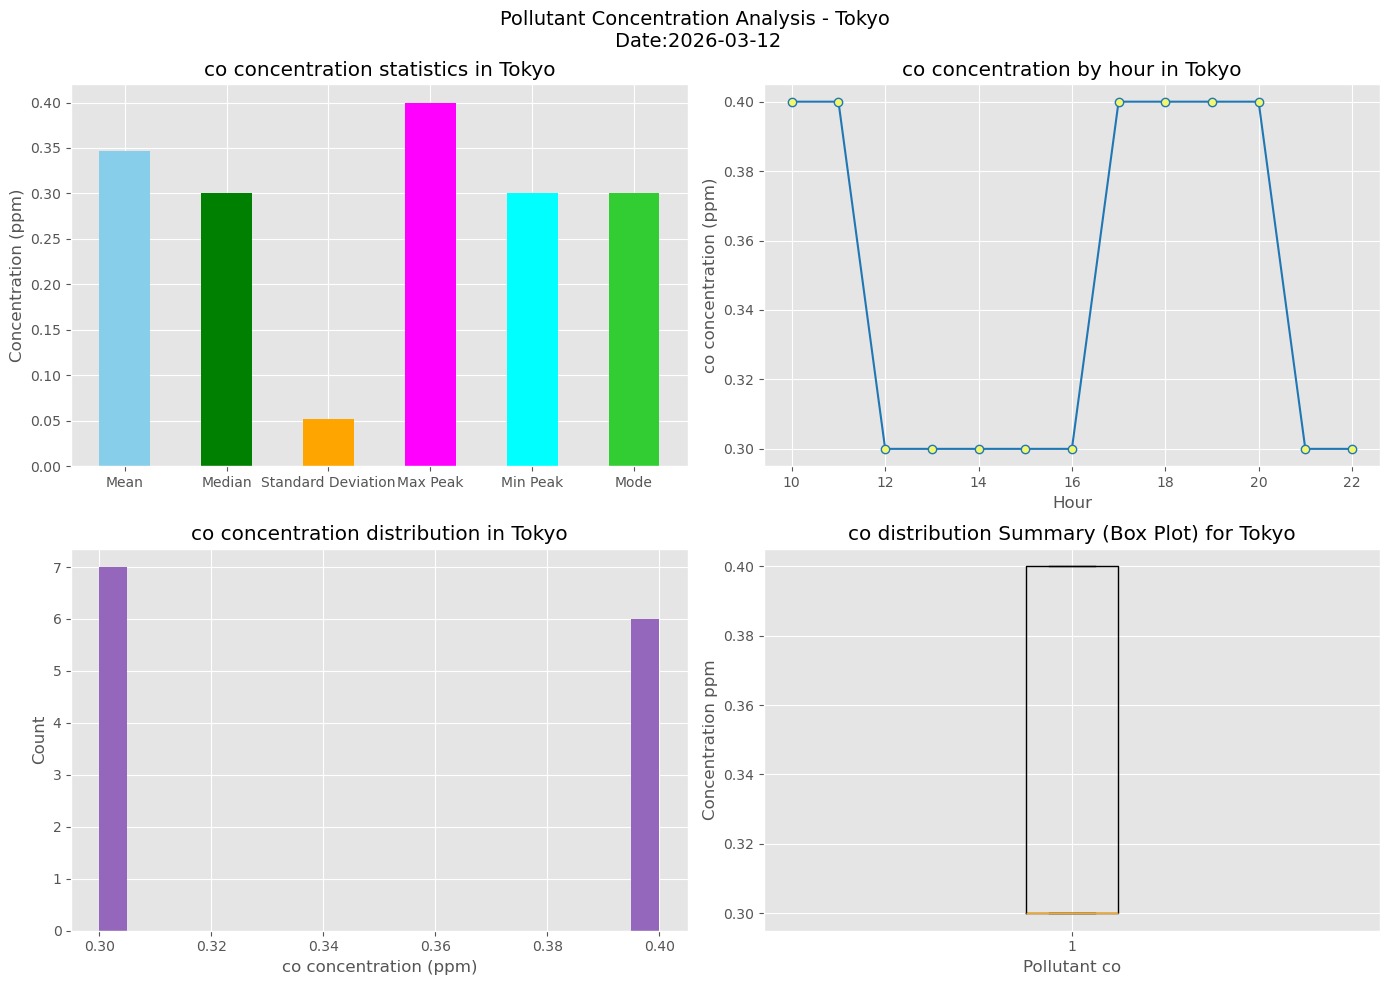

'o3' pollutant not found in the Tokyo dataframe.
'so2' pollutant not found in the Tokyo dataframe.


In [239]:
# Iterate through each city and pollutant dataset
# Generate four visualizations:
# 1) time series of hourly concentrations
# 2) statistical summary (mean, median, mode, std, max, min)
# 3) histogram distribution
# 4) box plot showing quartile spread

for city, pollutant_data in datasets.items():
    for pollutant, df in pollutant_data.items():
        if df.empty:
            print(f"'{pollutant}' pollutant not found in the {city} dataframe.")
        else:
            
            fig, ax = plt.subplots(2, 2, figsize=(14,10))
            fig.suptitle(f"Pollutant Concentration Analysis - {city}\n Date:{datasets[city][pollutant]["datetimeUtc"].dt.date.iloc[0]}", fontsize=14)
            ax[0, 0].bar("Mean", df["value"].mean(), color='skyblue', width=0.5)
            ax[0, 0].bar("Median", df["value"].median(), color='green', width=0.5)
            ax[0, 0].bar("Standard Deviation", datasets[city][pollutant]["value"].std(), color='orange', width=0.5)
            ax[0, 0].bar("Max Peak", df["value"].max(), color='magenta', width=0.5)
            ax[0, 0].bar("Min Peak", df["value"].min(), color='cyan', width=0.5)
            ax[0, 0].bar("Mode", datasets[city][pollutant]["value"].mode(), color='limegreen', width=0.5)
            ax[0, 0].set_ylabel(f'Concentration ({df["unit"].iloc[0]})')
            ax[0, 0].set_title(f"{pollutant} concentration statistics in {city}")
            ax[0,1].plot(df["datetimeLocal"].dt.hour, df["value"], color="tab:blue", marker="o", markerfacecolor="#F3F76D")
            ax[0,1].set_xlabel("Hour")
            ax[0,1].set_ylabel(f"{pollutant} concentration ({df["unit"].iloc[0]})")
            ax[0,1].set_title(f"{pollutant} concentration by hour in {city}")
            ax[1,0].hist(df["value"], bins=20, color="tab:purple")
            ax[1,0].set_xlabel(f"{pollutant} concentration ({df["unit"].iloc[0]})")
            ax[1,0].set_ylabel("Count")
            ax[1,0].set_title(f"{pollutant} concentration distribution in {city}")
            ax[1,1].boxplot(df["value"])
            ax[1,1].set_xlabel(f"Pollutant {pollutant}")
            ax[1,1].set_ylabel(f"Concentration {df["unit"].iloc[0]}")
            ax[1,1].set_title(f"{pollutant} distribution Summary (Box Plot) for {city}")
            plt.tight_layout()
            plt.show()
            plt.close()